# Split PROTACs Using Graph Algorithms

## Setup

In [2]:
from rdkit import Chem
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
import pandas as pd

data_dir = os.path.join(os.getcwd(), '..', 'data')

held_out_df = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs_with_manually_mapped.csv')).reset_index(drop=True)
print(f'Number of mapped PROTACs: {len(held_out_df):,}')

# Remove all entries with empty linker, i.e., [*:1][*:2] or [*:2][*:1]
held_out_df = held_out_df[~held_out_df['Linker SMILES with direction'].str.contains(r'\[\*\:1\]\[\*\:2\]|\[\*\:2\]\[\*\:1\]')]

# Double check if there are any empty linkers
for smi in held_out_df['Linker SMILES with direction']:
    if smi in ['[*:1][*:2]', '[*:2][*:1]']:
        print(smi)

print(f'Number of mapped PROTACs: {len(held_out_df):,} (after removing empty linkers)')

Number of mapped PROTACs: 5,679
Number of mapped PROTACs: 5,672 (after removing empty linkers)


In [4]:
train_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_train_protacs.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_val_protacs.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_test_protacs.csv'))
print(f'Number of generated PROTACs per train set: {len(train_df):,}')
print(f'Number of generated PROTACs per val set: {len(val_df):,}')
print(f'Number of generated PROTACs per test set: {len(test_df):,}')

Number of generated PROTACs per train set: 1,298,401
Number of generated PROTACs per val set: 11,330
Number of generated PROTACs per test set: 11,308


## Find Representative E3

We will use Tanimoto similarity to distinguish fragments of PROTACs: if one is more similar to the representatives, then it's an E3 ligase and the other is the warhead.

In [5]:
from tqdm import tqdm
from rdkit.Chem import rdFingerprintGenerator
from protac_splitter.chemoinformatics import remove_dummy_atoms

def get_fp(smiles: str, fp_generator, return_np = True):
    """
    Get the Morgan fingerprint of a molecule from its SMILES representation.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = fp_generator.GetFingerprint(mol)
    if return_np:
        return np.array(fp)
    else:
        return fp

# Get the fingerprints:
morgan_fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

# fp_dict = {smi: get_fp(remove_dummy_atoms(smi), morgan_fp_generator) for smi in train_df['E3 Binder SMILES with direction']}
fp_dict = {}
for smi in tqdm(train_df['E3 Binder SMILES with direction'].unique()):
    fp = get_fp(remove_dummy_atoms(smi), morgan_fp_generator)
    if fp is not None:
        fp_dict[smi] = fp

fp_list = list(fp_dict.values())
fp2smiles = {fp.tobytes(): smi for smi, fp in fp_dict.items() if fp is not None}

100%|██████████| 217/217 [00:00<00:00, 824.87it/s]


In [6]:
from typing import List
from sklearn.cluster import AgglomerativeClustering, KMeans


def get_umap_clusters_fp(fp_list: List[str], n_clusters: int = 7) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the umap clustering algorithm.
    From Scaffold Splits Overestimate Virtual Screening Performance
    https://arxiv.org/abs/2406.00873

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac.fit_predict(np.stack(fp_list))
    return ac.labels_


def get_kmeans_clusters_fp(fp_list: List[str], n_clusters: int = 10, return_centroids: bool = False) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the KMeans clustering algorithm.

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42, max_iter=1000)
    if return_centroids:
        km.fit(np.stack(fp_list))
        return km.labels_, km.cluster_centers_
    return km.fit_predict(np.stack(fp_list))

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import skew
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "avg_cluster_data_ratio": 1,
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "median_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    avg_cluster_data_ratio = avg_cluster_size / len(X)
    std_cluster_size = np.std(cluster_sizes)
    median_cluster_size = np.median(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "avg_cluster_data_ratio": avg_cluster_data_ratio,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "median_cluster_size": median_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }

In [8]:
centroids_dict = {}
clusters_dict = {}
metrics_df = []
for n_clusters in tqdm([10, 25, 50, 100, 150], desc="Clustering and evaluating"):
    clusters, centroids = get_kmeans_clusters_fp(fp_list, n_clusters=n_clusters, return_centroids=True)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'kmeans_n{n_clusters}'] = clusters.copy()
    centroids_dict[n_clusters] = centroids.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'kmeans'
    metrics_df.append(metrics.copy())
    
    clusters = get_umap_clusters_fp(fp_list, n_clusters=n_clusters)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'umap_n{n_clusters}'] = clusters.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'umap'
    metrics_df.append(metrics.copy())

metrics_df = pd.DataFrame(metrics_df)
metrics_df

Clustering and evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.24it/s]


,silhouette,davies_bouldin,calinski_harabasz,avg_cluster_size,avg_cluster_data_ratio,std_cluster_size,min_cluster_size,median_cluster_size,max_cluster_size,cluster_size_skewness,num_clusters,cluster_algorithm
0,0.129261,2.339718,11.075803,21.60,0.100000,16.107141,4,13.5,51,0.717375,10,kmeans
1,0.130445,2.498744,11.447681,21.60,0.100000,12.745195,10,18.0,57,1.998905,10,umap
2,0.097943,2.022271,6.848378,8.64,0.040000,7.796820,1,6.0,28,1.506546,25,kmeans
3,0.143704,1.906168,8.085622,8.64,0.040000,5.520000,3,6.0,22,1.245416,25,umap
4,0.141041,1.507718,5.702807,4.32,0.020000,3.378994,1,3.5,17,1.496276,50,kmeans
5,0.177476,1.406123,6.558838,4.32,0.020000,3.120513,1,3.0,14,1.384148,50,umap
6,0.144744,0.948280,5.358977,2.16,0.010000,2.175868,1,1.0,15,3.300843,100,kmeans
7,0.193347,0.803857,5.984029,2.16,0.010000,1.770424,1,1.0,11,2.092438,100,umap
8,0.132977,0.607510,6.001038,1.44,0.006667,1.098362,1,1.0,8,3.443129,150,kmeans
9,0.161600,0.563959,6.743728,1.44,0.006667,0.883025,1,1.0,6,2.680470,150,umap


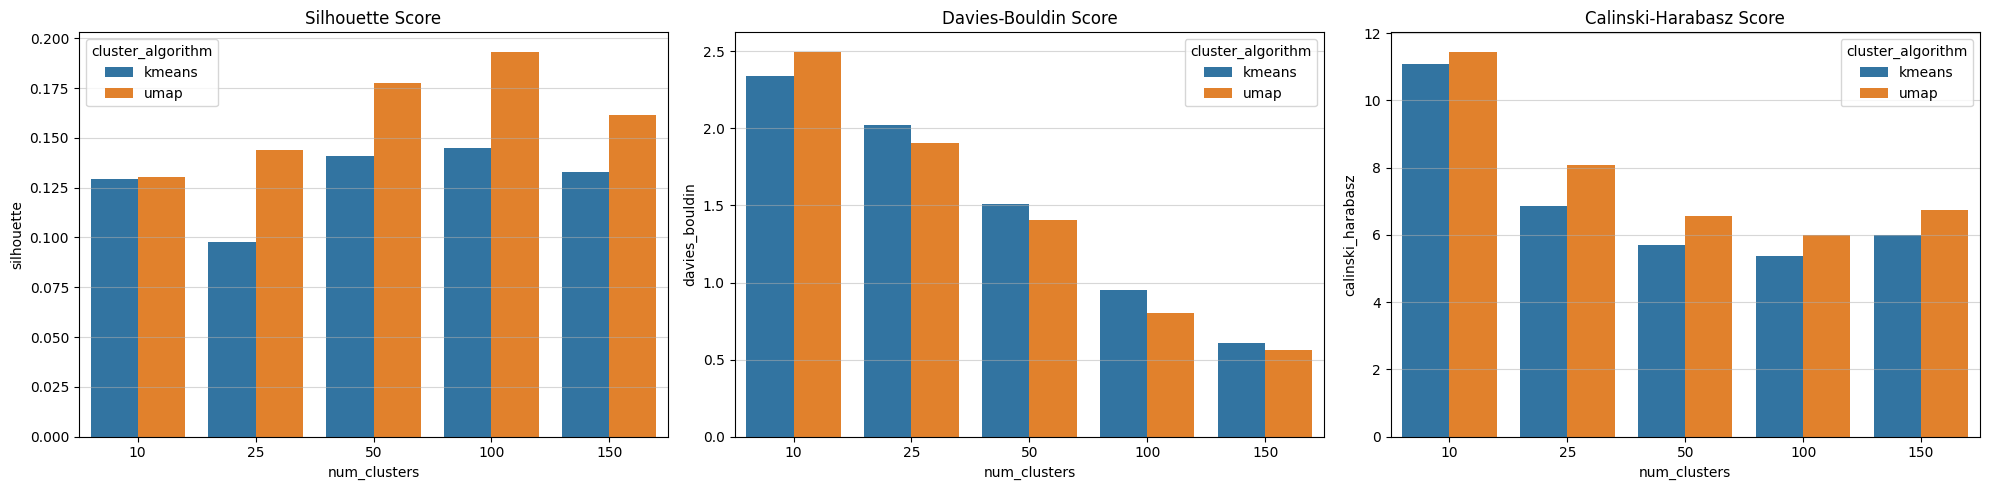

In [9]:
# Bar-plot silhouette score, Davies-Bouldin score, and Calinski-Harabasz score, hue by the clustering algorithm
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=metrics_df, x='num_clusters', y='silhouette', hue='cluster_algorithm', ax=axs[0])
axs[0].set_title('Silhouette Score')
sns.barplot(data=metrics_df, x='num_clusters', y='davies_bouldin', hue='cluster_algorithm', ax=axs[1])
axs[1].set_title('Davies-Bouldin Score')
sns.barplot(data=metrics_df, x='num_clusters', y='calinski_harabasz', hue='cluster_algorithm', ax=axs[2])
axs[2].set_title('Calinski-Harabasz Score')
plt.tight_layout()
for ax in axs:
    ax.grid(axis='y', alpha=0.5)
plt.show()

From above plots, 50 seems to be a good choice for the number of clusters.

In [10]:
# Get the centroids of the clusters
best_n_clusters = 50
centroids = centroids_dict[best_n_clusters]

# Get the cluster labels for the centroids
clusters = np.array(clusters_dict[f'kmeans_n{n_clusters}'])
representative_e3s = []
representative_e3s_fp = []
for label, centroid in enumerate(centroids):
    # Isolate the FP with the same label as the centroid
    fp_cluster = np.array(fp_list)[clusters == label]
    # Get the closest FP for the centroid, use euclidean distance
    distances = np.linalg.norm(fp_cluster - centroid, axis=1)
    closest_fp = np.argmin(distances)
    # To get the SMILES from the FP, use the fp2smiles dictionary
    closest_smiles = fp2smiles[fp_cluster[closest_fp].tobytes()]
    # Append the closest SMILES to the representative_e3s list
    representative_e3s.append(closest_smiles)
    representative_e3s_fp.append(fp_cluster[closest_fp])

# print(representative_e3s_fp)

In [11]:
from rdkit import DataStructs


def numpy_to_rdkit_fp(arr: np.ndarray) -> DataStructs.ExplicitBitVect:
    """
    Convert a NumPy array to an RDKit ExplicitBitVect.
    """
    return DataStructs.CreateFromBitString(''.join(arr.astype(str)))

representative_e3s_fp = [numpy_to_rdkit_fp(fp) for fp in representative_e3s_fp]

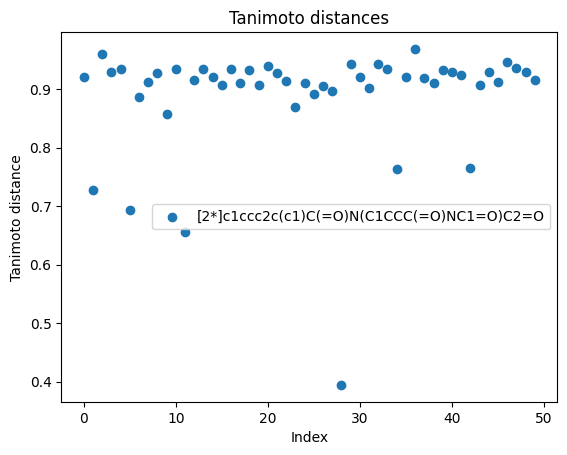

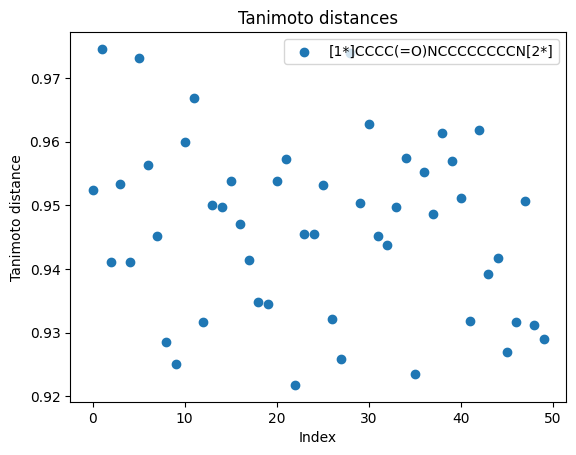

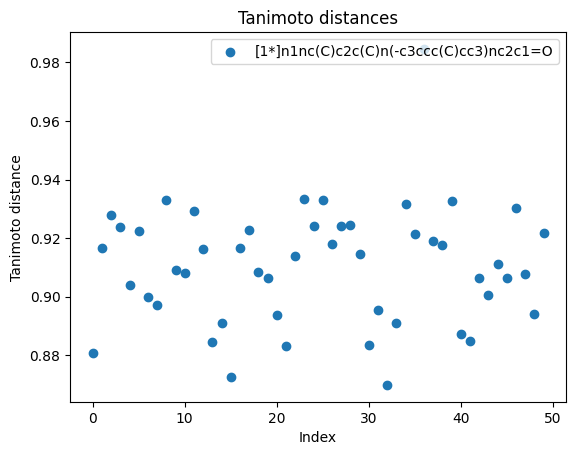

Average Tanimoto distance for E3:      0.8901141956803234
Average Tanimoto distance for Linker:  0.9464029513530192
Average Tanimoto distance for Warhead: 0.9105967829251957


In [12]:
def average_tanimoto_distance(smiles, fingerprints, morgan_fp_generator, show_plot=False):
    """
    Compute the average Tanimoto distance between a query SMILES and a list of RDKit fingerprints.

    Parameters:
        smiles (str): SMILES string of the query molecule.
        fingerprints (list): List of RDKit fingerprint objects (e.g., ExplicitBitVect).
        morgan_fp_generator: RDKit Morgan fingerprint generator.

    Returns:
        float: Average Tanimoto distance (1 - similarity) between the query and the fingerprints.
    """
    query_fp = get_fp(smiles, morgan_fp_generator, return_np=False)
    if query_fp is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")
    distances = DataStructs.BulkTanimotoSimilarity(query_fp, fingerprints, returnDistance=True)

    if show_plot:
        # Scatter plot the distances
        plt.scatter(range(len(distances)), distances, label=smiles)
        plt.xlabel('Index')
        plt.ylabel('Tanimoto distance')
        plt.title('Tanimoto distances')
        plt.legend()
        plt.show()

    return np.array(distances).mean()


e3_sample = "[2*]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O"
lk_sample = "[1*]CCCC(=O)NCCCCCCCCN[2*]"
wh_sample = "[1*]n1nc(C)c2c(C)n(-c3ccc(C)cc3)nc2c1=O"

# Get the average Tanimoto distance for the E3 ligands
avg_tanimoto_e3 = average_tanimoto_distance(e3_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)
avg_tanimoto_lk = average_tanimoto_distance(lk_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)
avg_tanimoto_wh = average_tanimoto_distance(wh_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)

print(f"Average Tanimoto distance for E3:      {avg_tanimoto_e3}")
print(f"Average Tanimoto distance for Linker:  {avg_tanimoto_lk}")
print(f"Average Tanimoto distance for Warhead: {avg_tanimoto_wh}")

## Graph-Based Algorithm

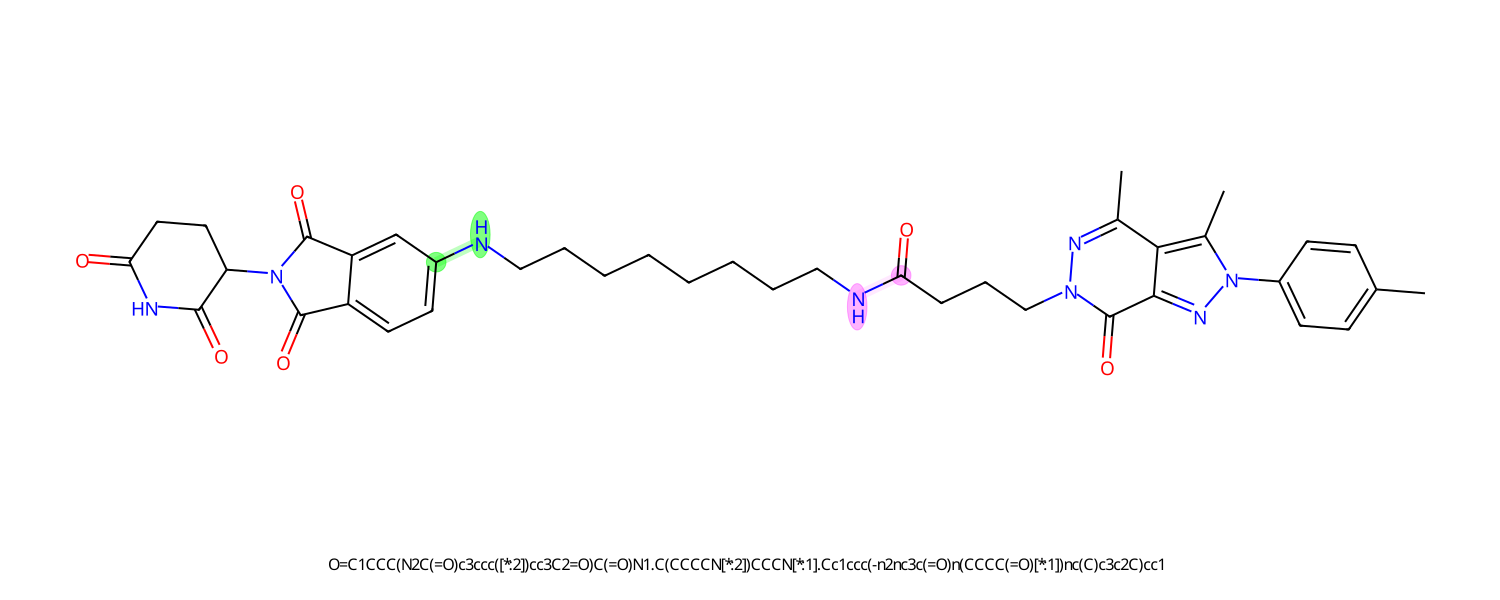

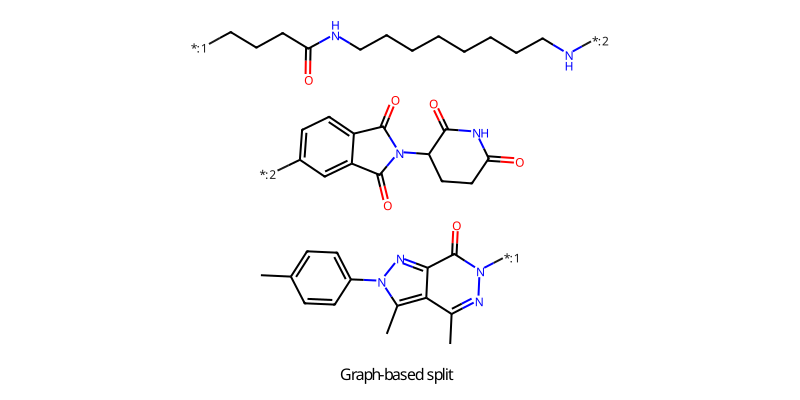

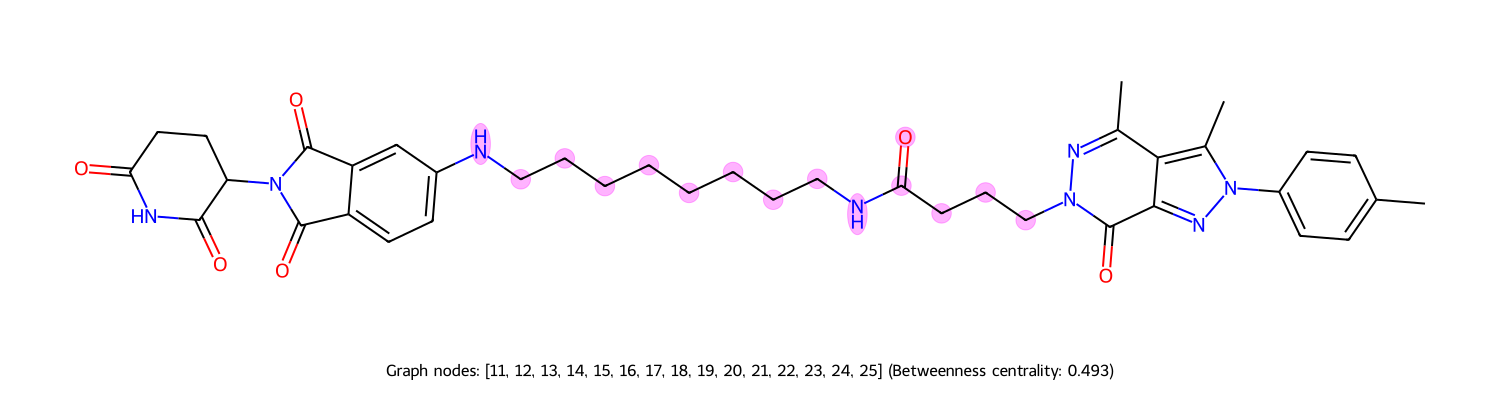

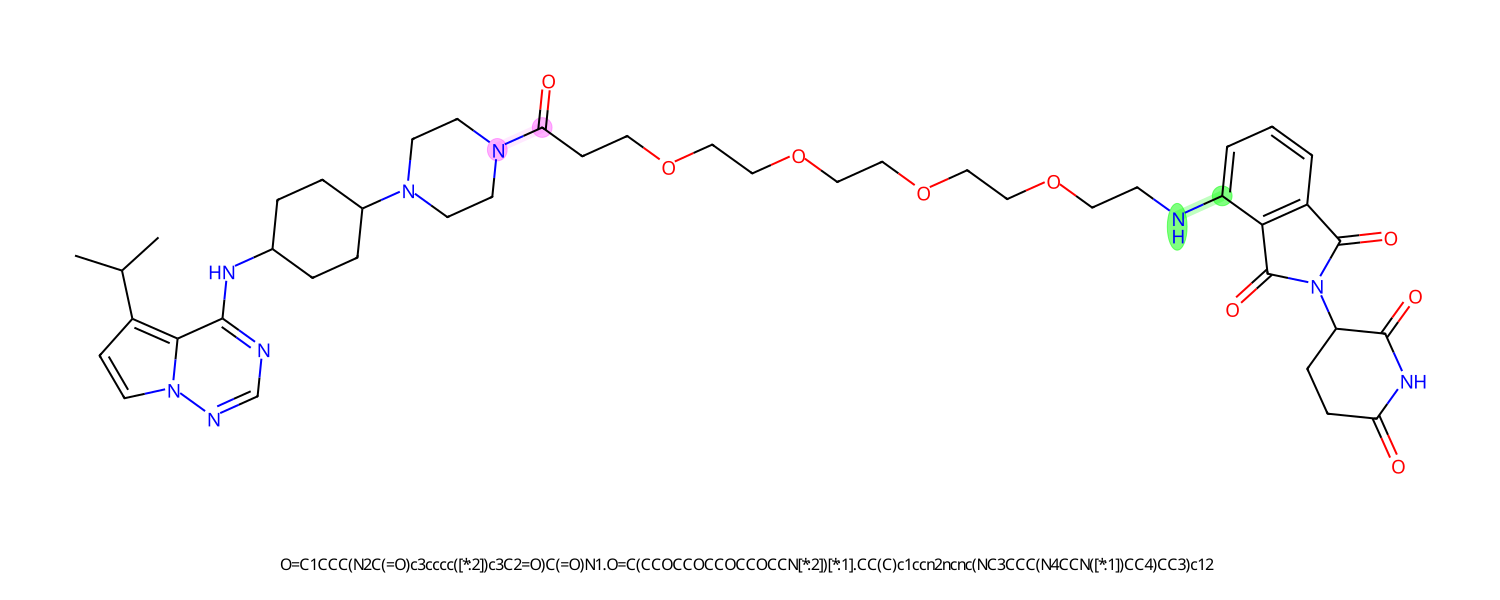

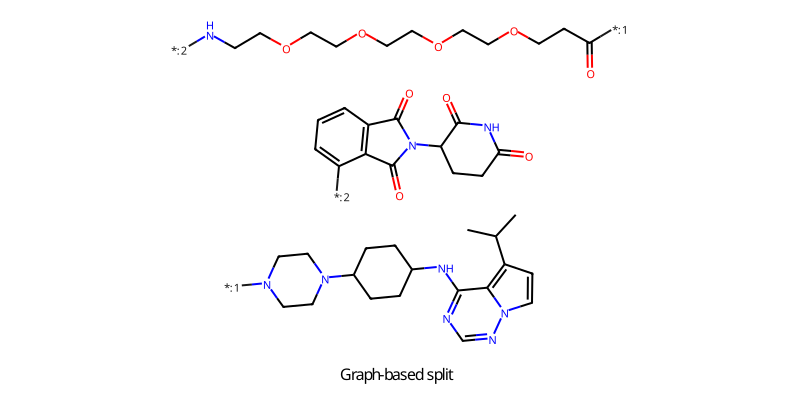

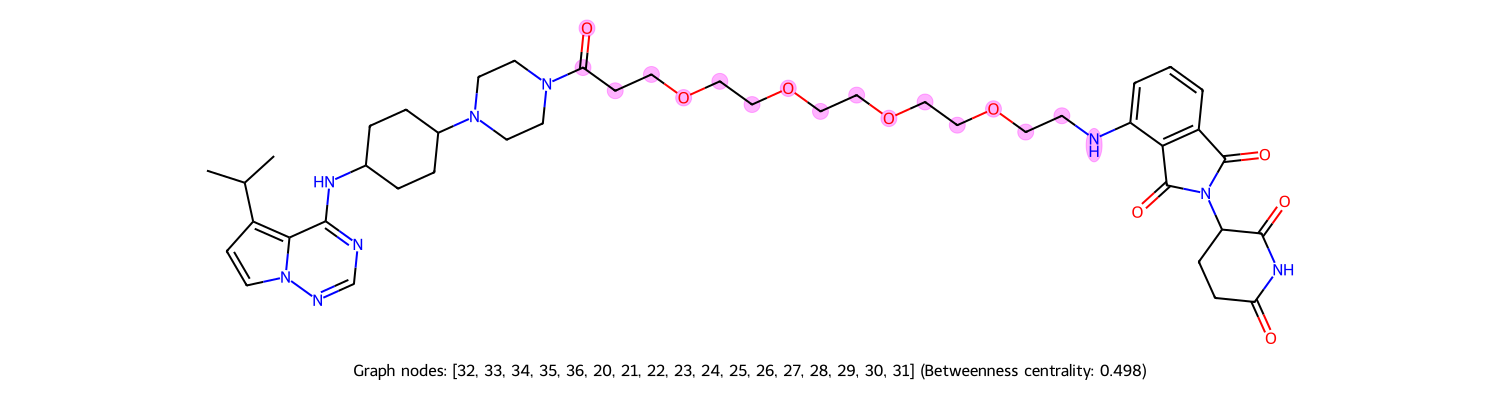

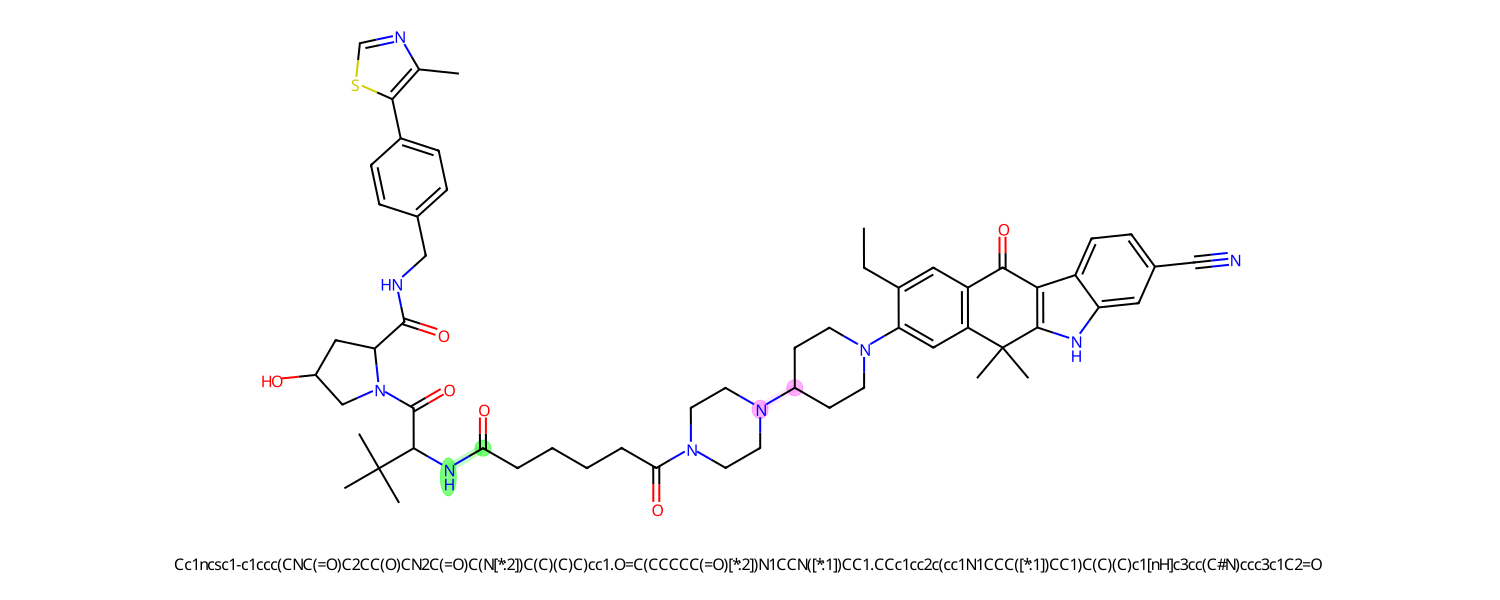

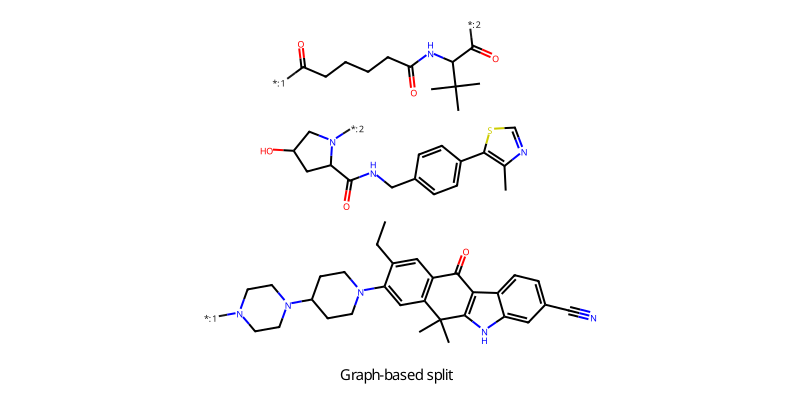

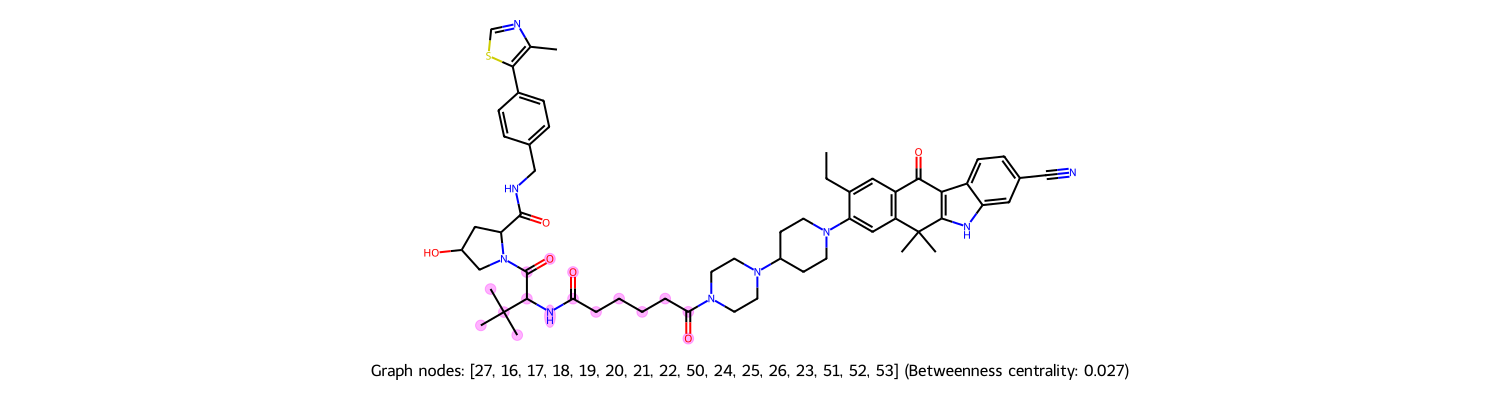

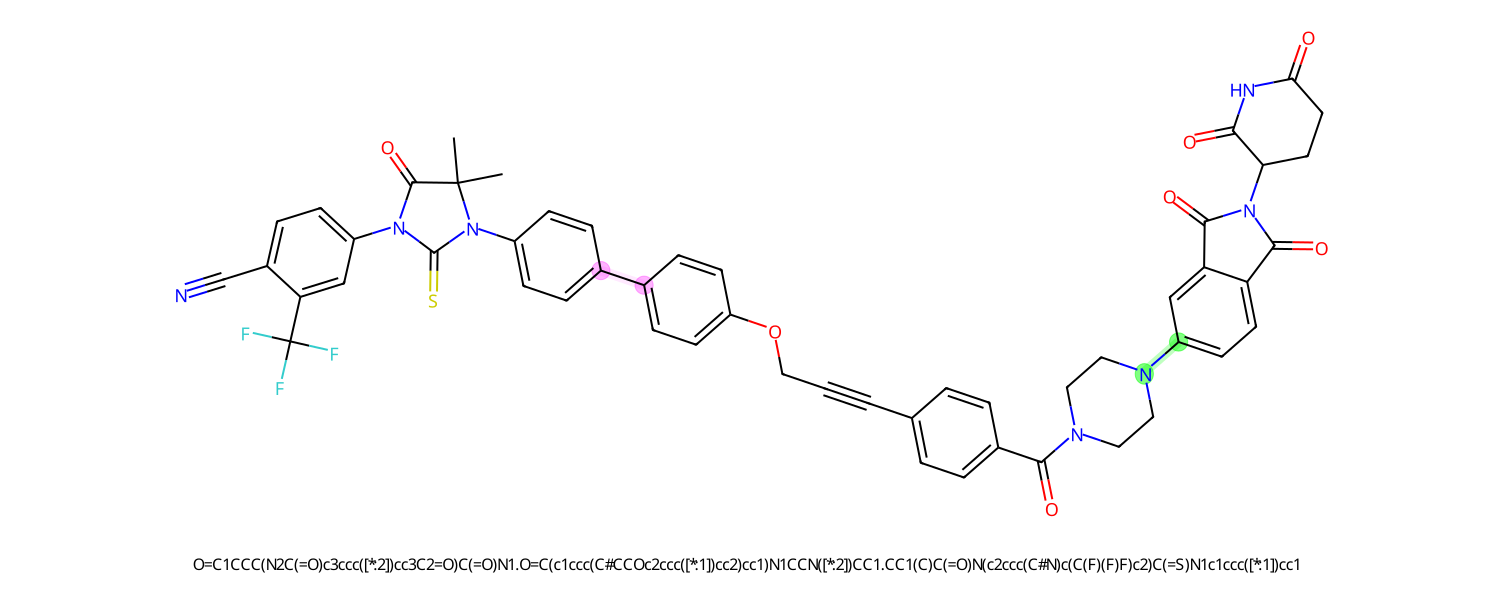

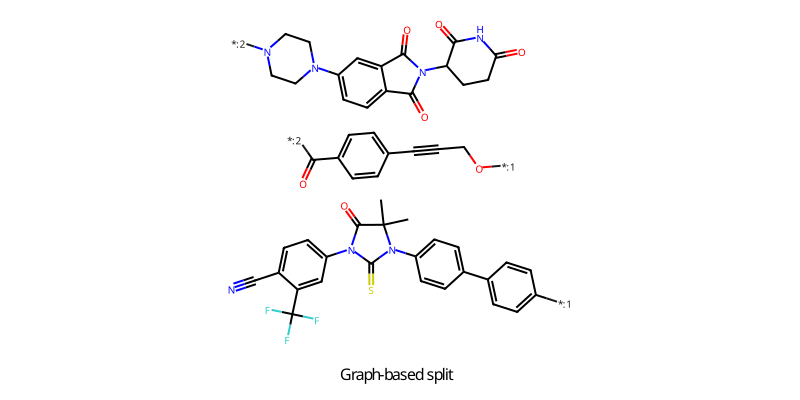

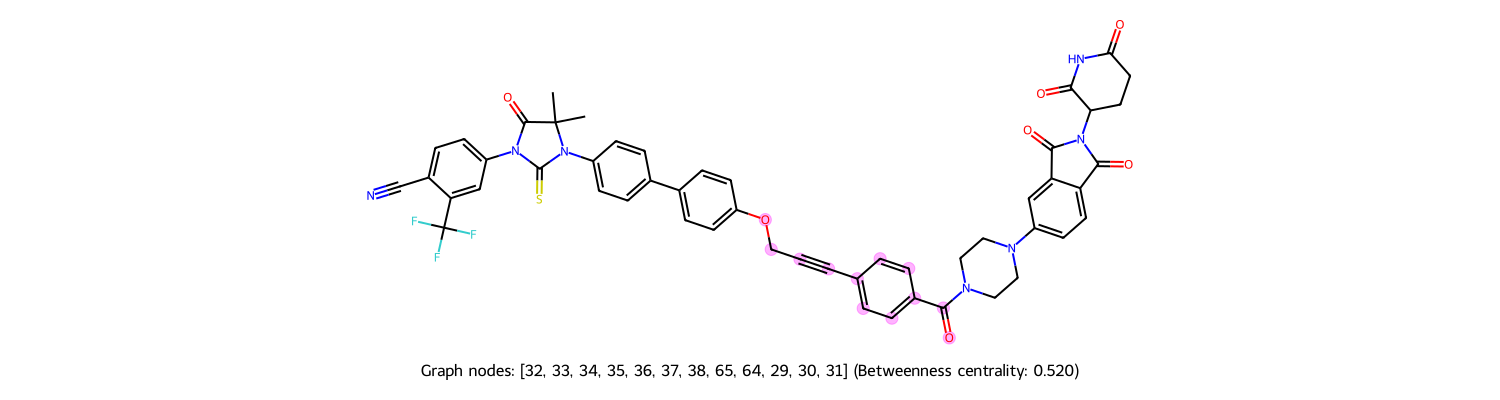

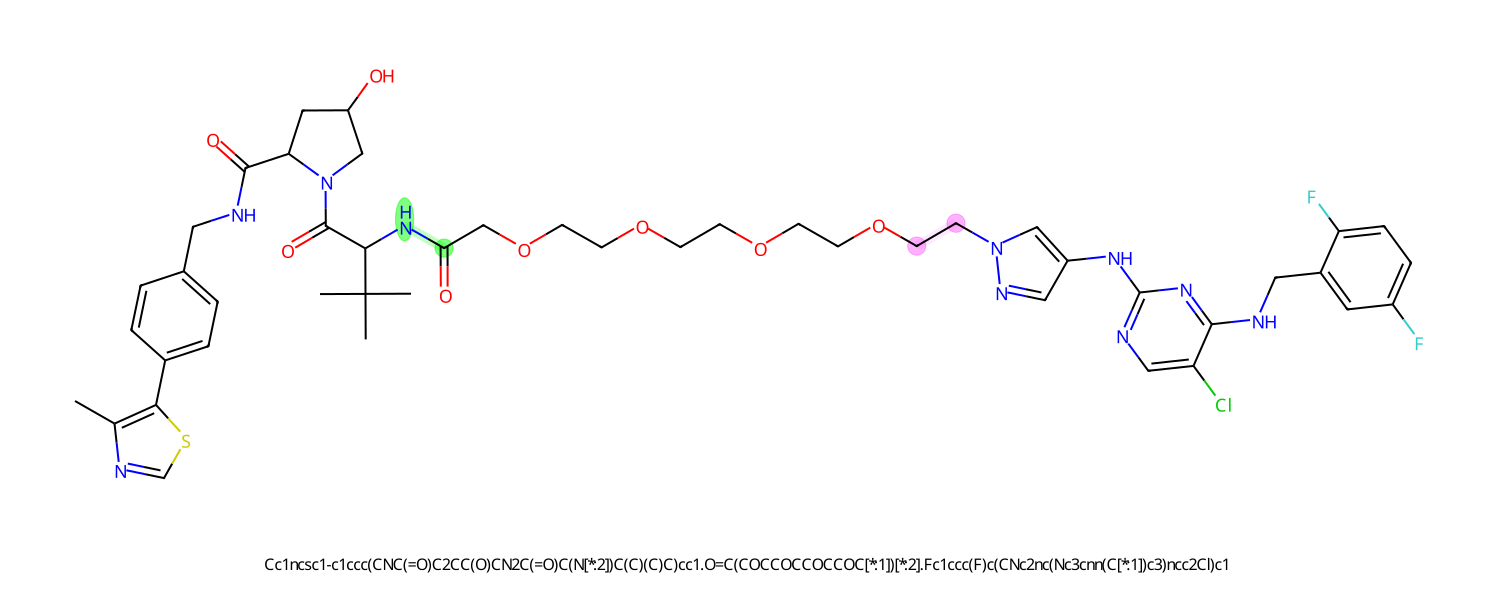

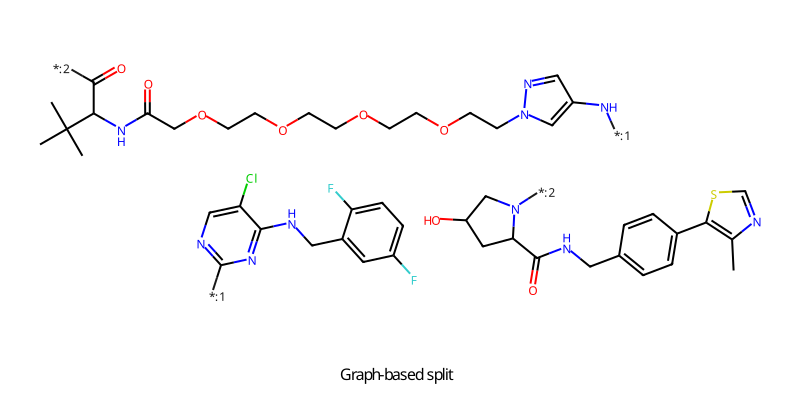

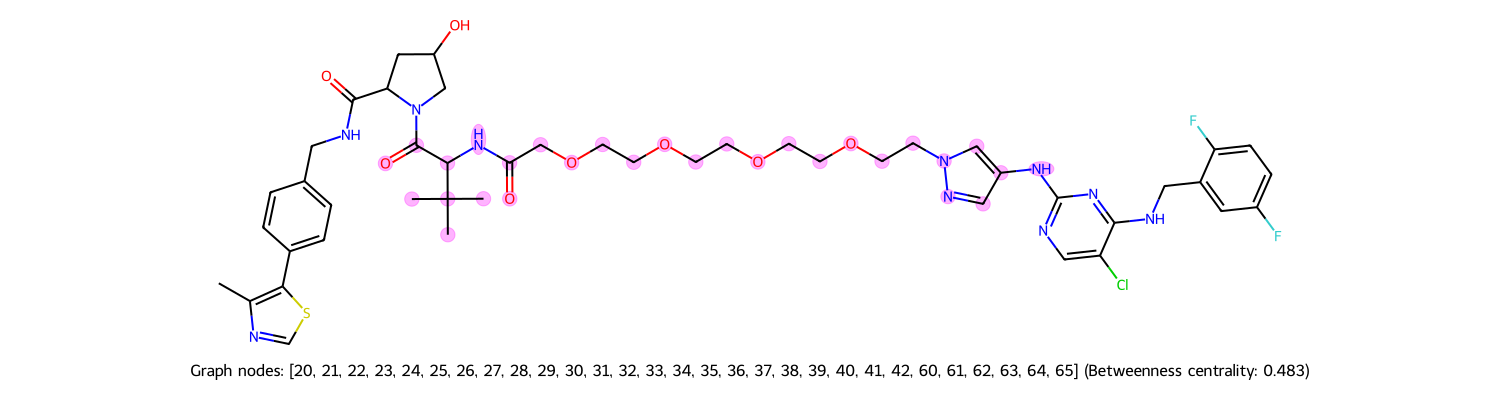

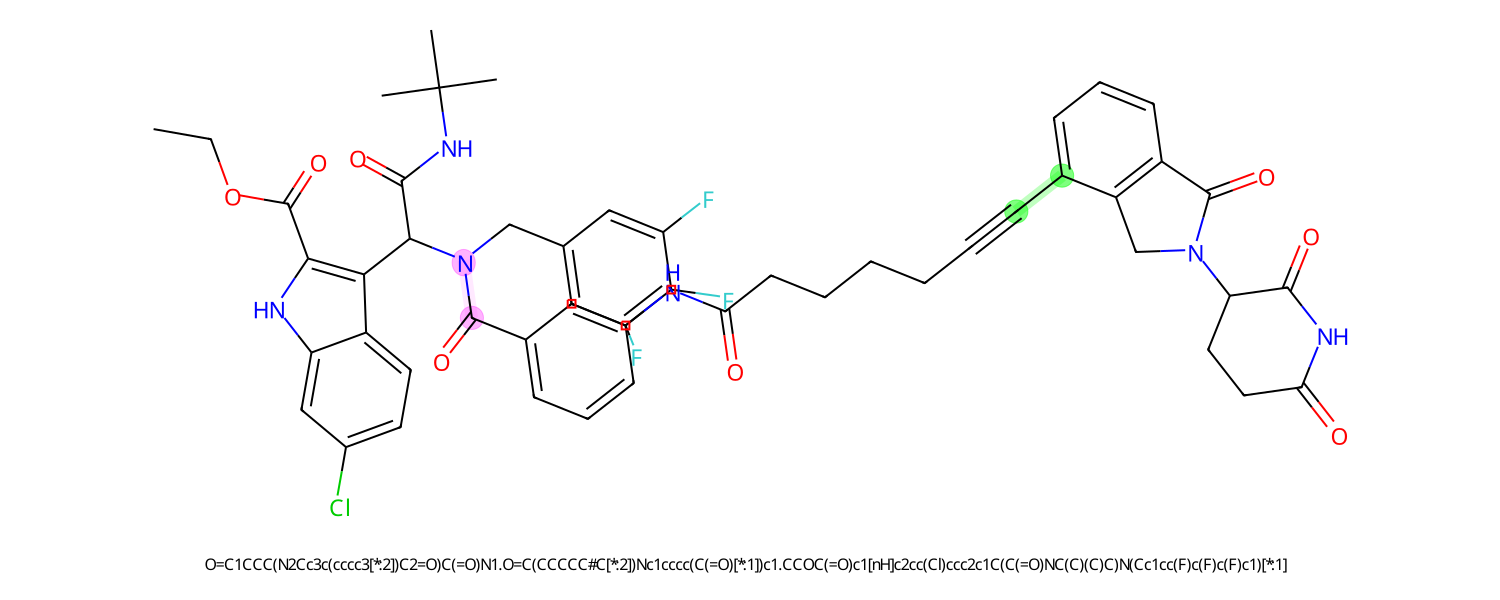

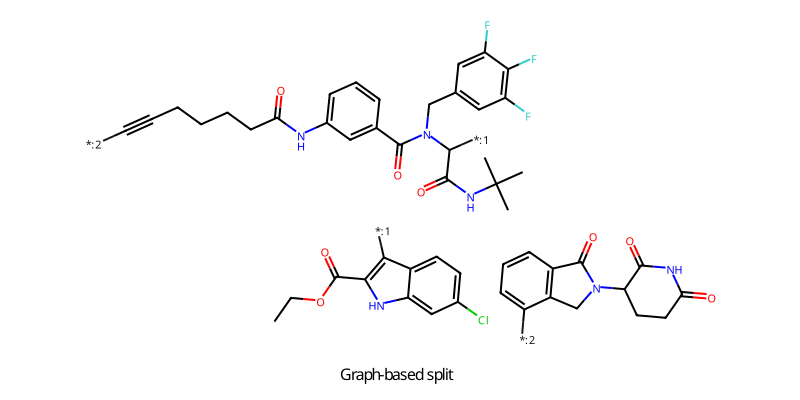

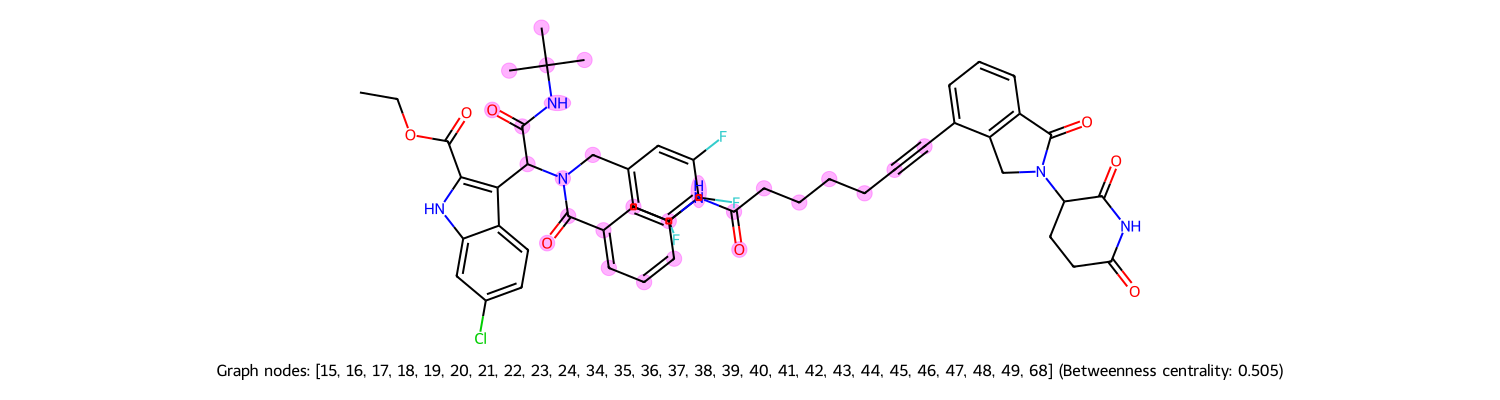

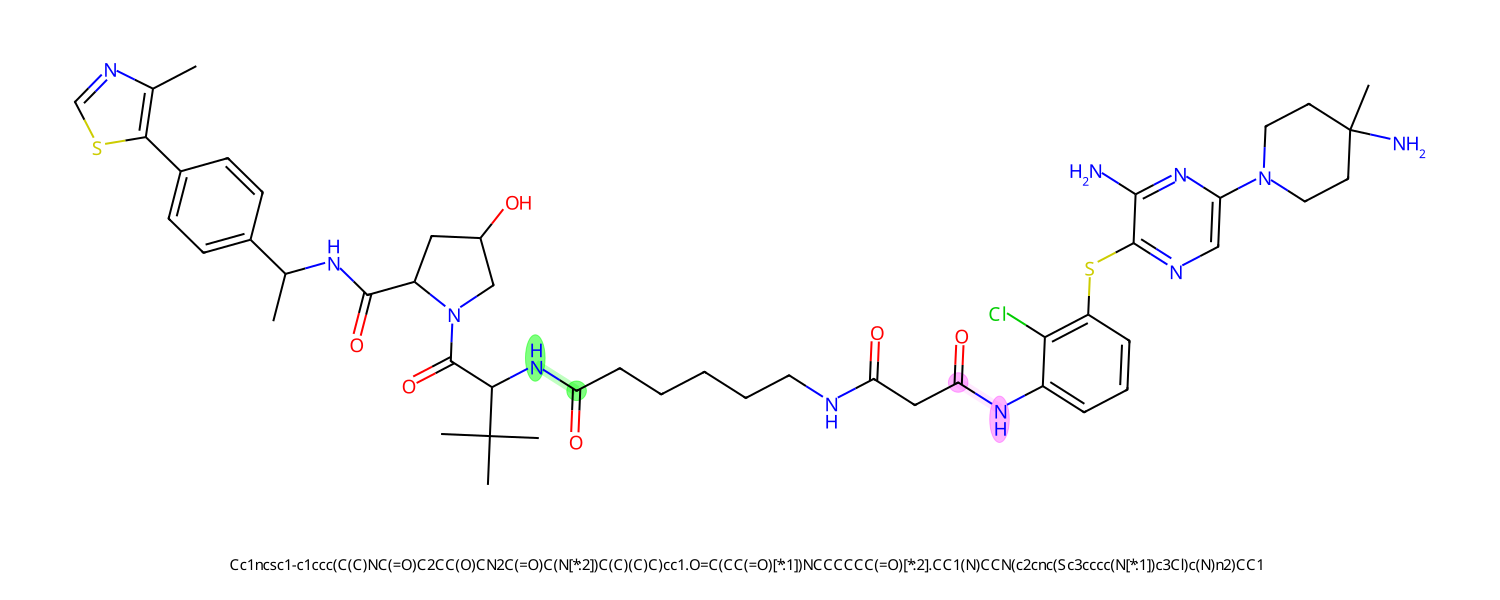

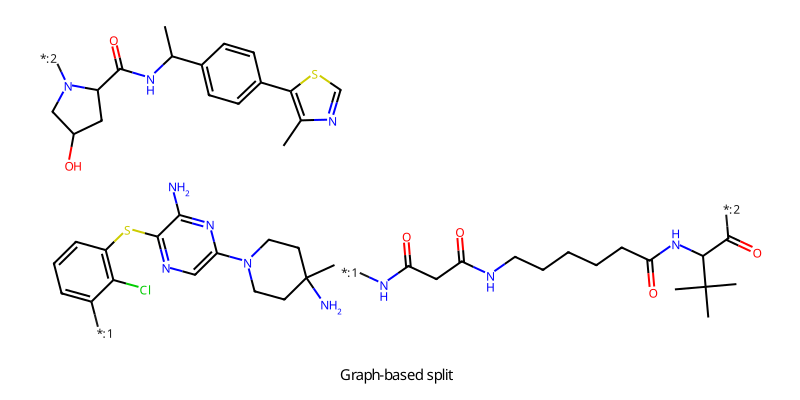

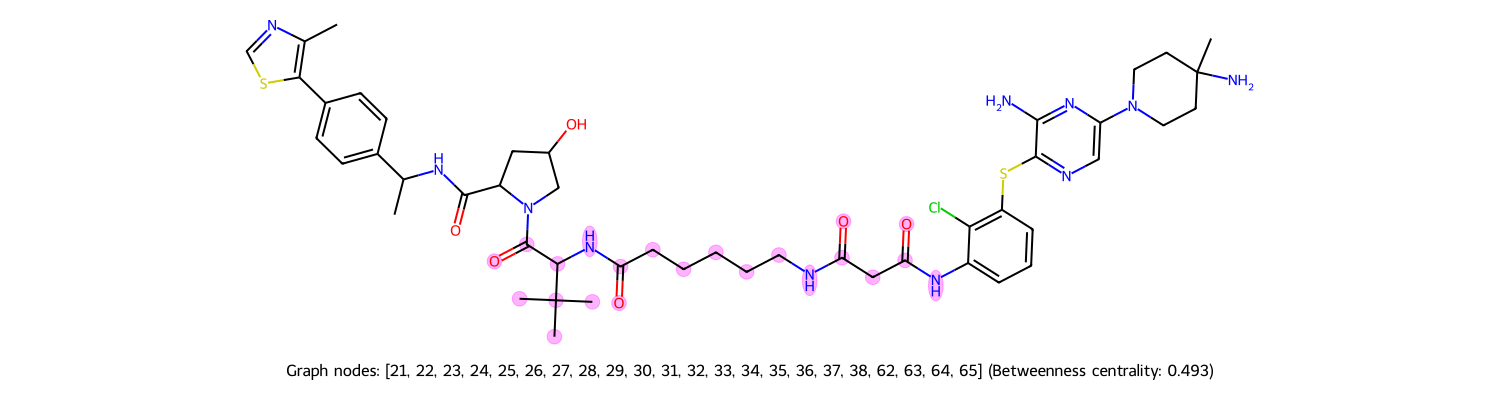

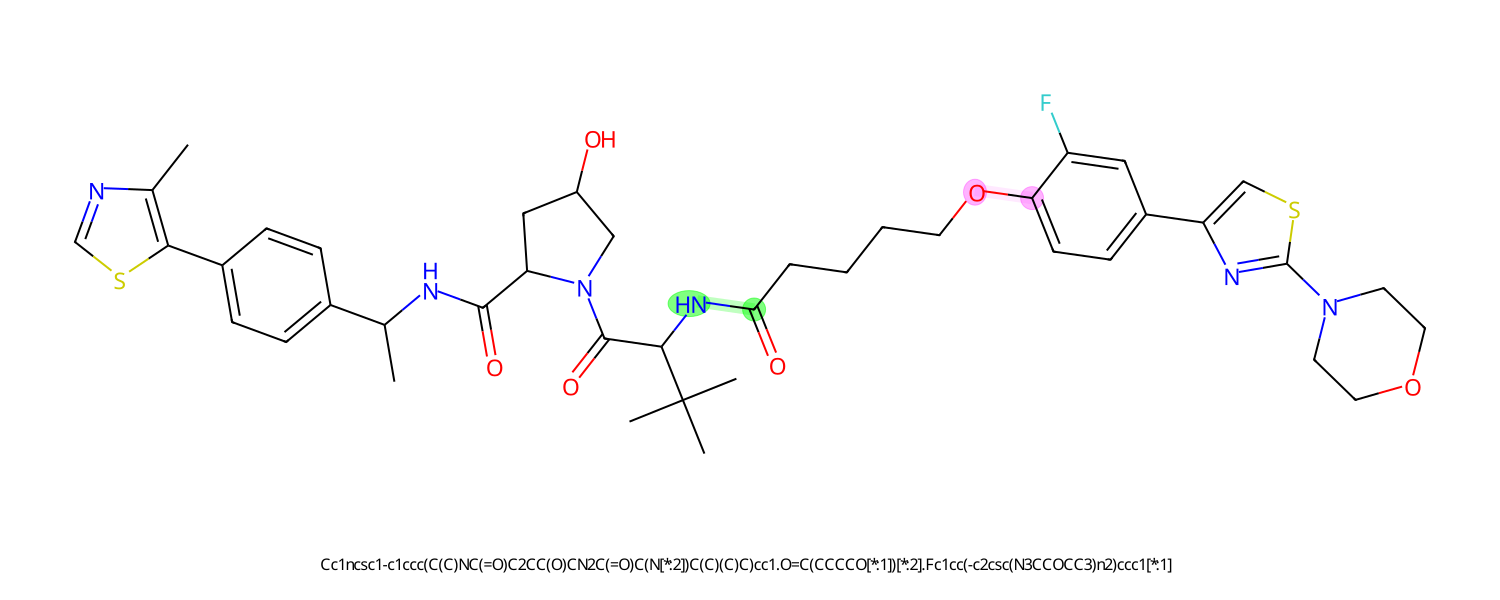

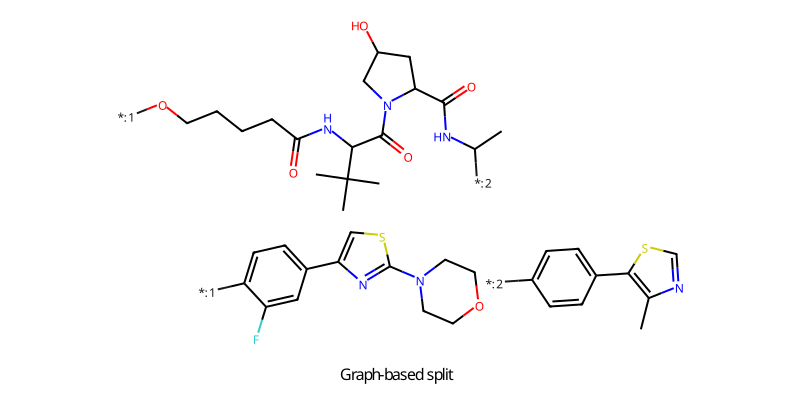

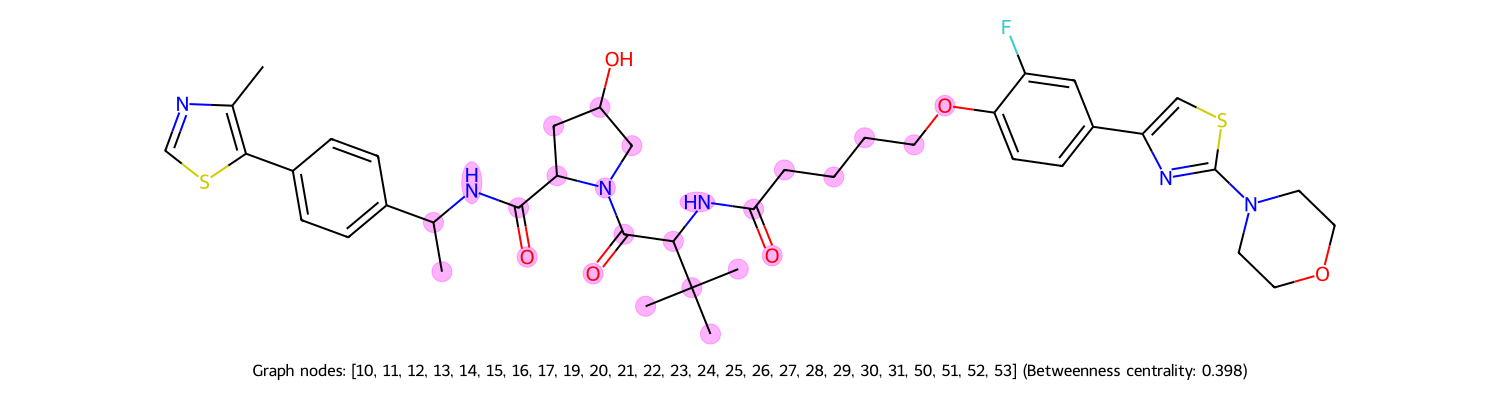

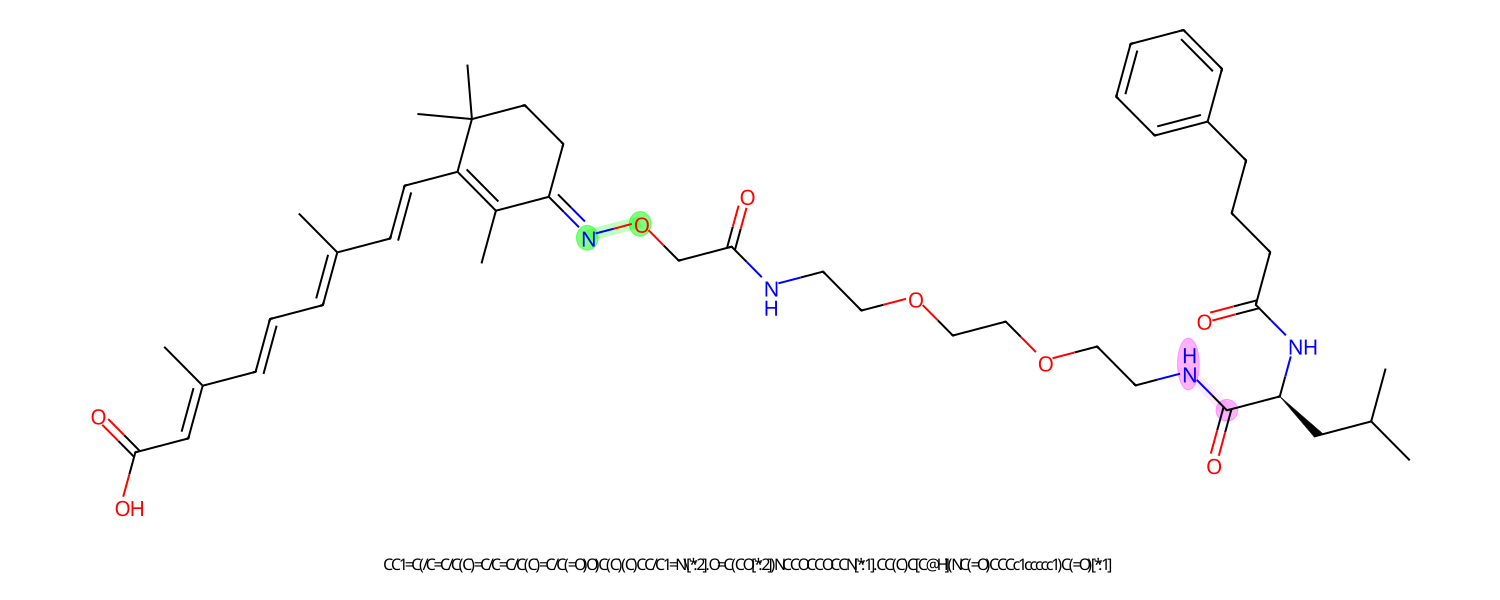

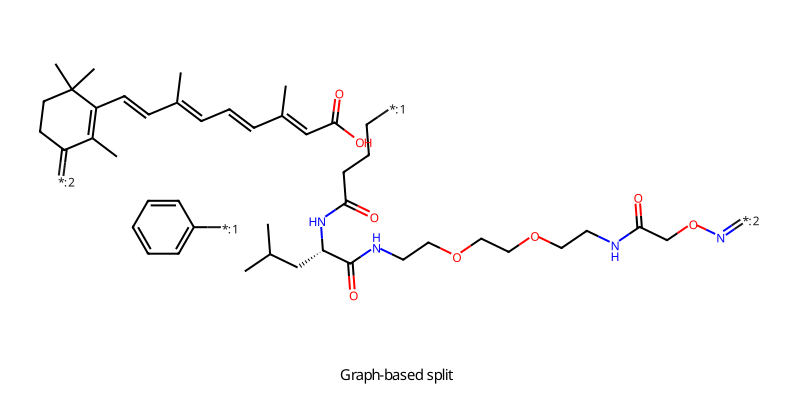

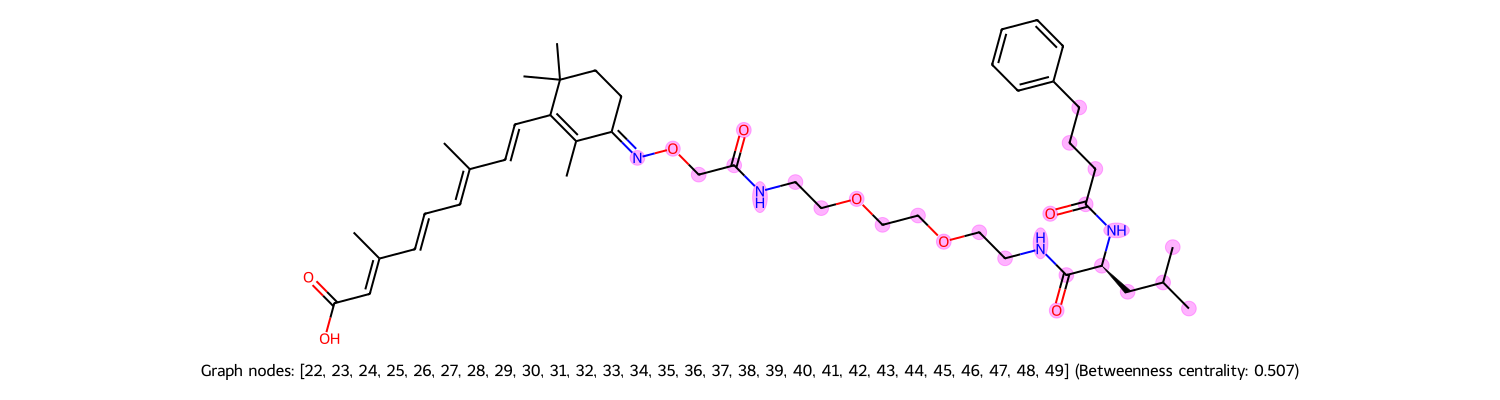

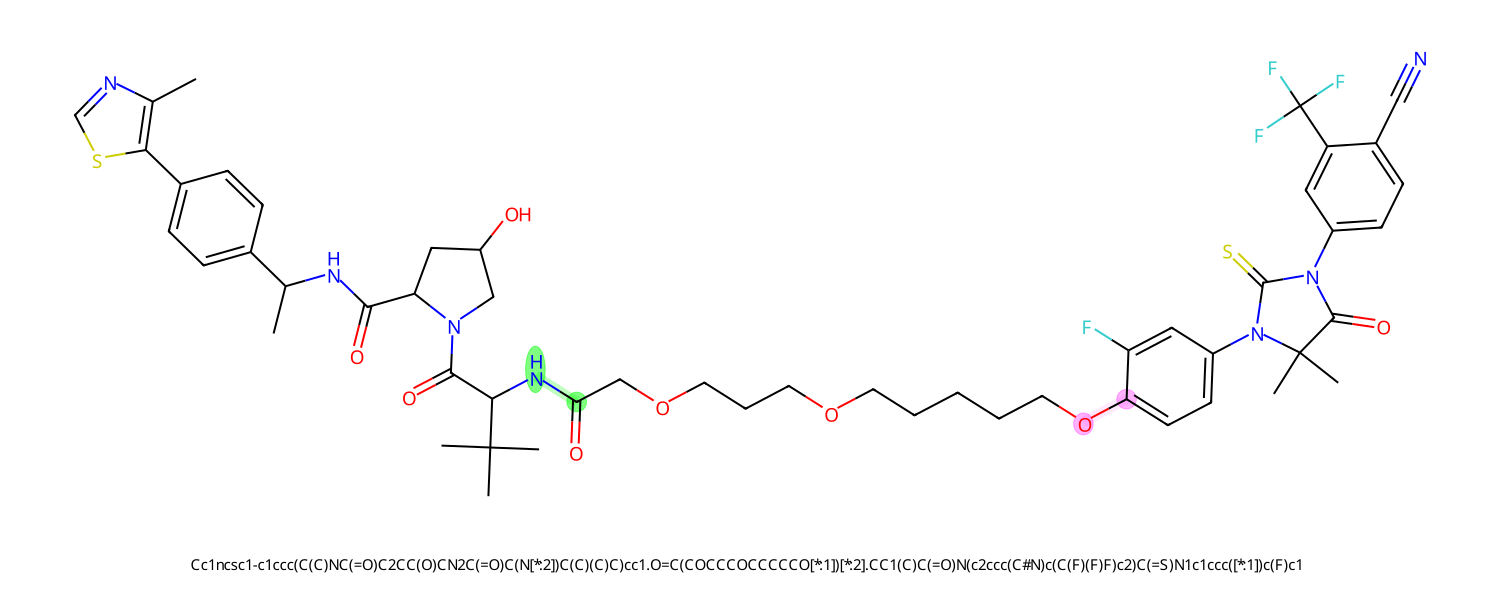

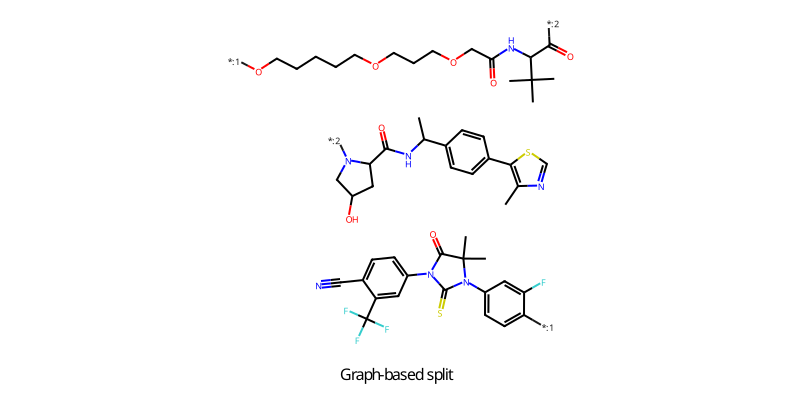

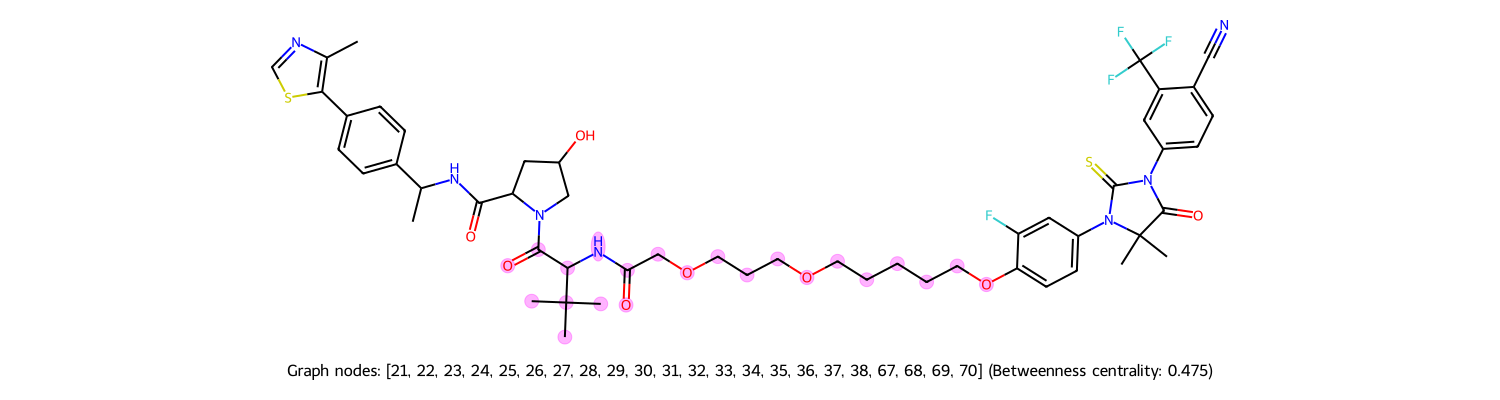

In [14]:
from typing import Dict
import re
from protac_splitter.display_utils import display_mol, get_mapped_protac_img
from protac_splitter.chemoinformatics import get_atom_idx_at_attachment
from rdkit.Chem import Draw

def bond_capacity(bond):
    if bond.GetIsAromatic() or bond.IsInRing():
        return 1000  # very high capacity: avoid cutting aromatic bonds
    elif bond.GetBondType() == Chem.BondType.SINGLE:
        return 1     # low capacity: prefer to cut here
    elif bond.GetBondType() == Chem.BondType.DOUBLE:
        return 10    # medium penalty
    elif bond.GetBondType() == Chem.BondType.TRIPLE:
        return 20    # stronger penalty
    else:
        return 50    # fallback for unknown/rare types

def smiles_to_nx(smiles):
    mol = Chem.MolFromSmiles(smiles)
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), element=atom.GetSymbol())
    for bond in mol.GetBonds():
        capacity = bond_capacity(bond)
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=bond.GetBondType(), capacity=capacity)
    return G

def extract_attachment_point(smiles):
    """
    Extracts the number X from the pattern [X*] in a SMILES string.

    Parameters:
        smiles (str): The SMILES string containing the attachment point.

    Returns:
        str or None: The extracted number as a string, or None if not found.
    """
    match = re.search(r'\[(\d+)\*\]', smiles)
    return match.group(1) if match else None

def nx_split(protac_smiles, representative_e3s_fp, morgan_fp_generator, use_capacity_weight = False, betweenness_threshold = 0.4) -> Dict[str, str]:
    """
    Split the PROTAC molecule into two parts using the NetworkX library.
    
    Parameters:
        protac_smiles (str): The SMILES string of the PROTAC molecule.
        representative_e3s_fp (list): List of representative E3 ligands fingerprints.
        morgan_fp_generator: RDKit Morgan fingerprint generator (should be the same as the one that generated the E3 fingerprints).
        use_capacity_weight (bool): Whether to use bond capacity as weight for the graph.
        betweenness_threshold (float): Threshold for betweenness centrality to consider a node as a candidate for splitting.
        
    Returns:
        dict: A dictionary containing the E3 ligand, warhead, linker, top nodes, and max centrality score.
    """
    # -----------------------------------
    # Deterministic graph-based algorithm
    # -----------------------------------
    protac = Chem.MolFromSmiles(protac_smiles)
    if protac is None:
        raise ValueError(f"Invalid SMILES string: {protac_smiles}")

    G = smiles_to_nx(protac_smiles)

    # Compute betweenness centrality
    weight = 'capacity' if use_capacity_weight else None
    centrality = nx.betweenness_centrality(G, normalized=True, endpoints=True, weight=weight)

    # Get the two nodes with the highest betweenness centrality
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)

    # Get the top two nodes
    top_nodes = [n for n, _ in sorted_nodes][:2]

    # Get the top nodes with the highest betweenness centrality that are not in
    # a ring, but are adjacent to the top nodes or have a high betweenness
    for node, score in sorted_nodes:
        # Check if the node is in a ring in the protac molecule
        atom = protac.GetAtomWithIdx(node)
        if not atom.IsInRing():
            # Check if the atom is adjacent to any of the top nodes, if so, add it to the list
            for neighbor in G.neighbors(node):
                if neighbor in top_nodes:
                    top_nodes.append(node)
                    break
            if score > betweenness_threshold:
                top_nodes.append(node)

    # If a node as only top nodes as neighbors, add it to the list
    for node in G.nodes():
        if node not in top_nodes:
            neighbors = list(G.neighbors(node))
            if all(neighbor in top_nodes for neighbor in neighbors):
                top_nodes.append(node)

    # Get all paths between the top nodes, e.g., rings
    for i in range(len(top_nodes)):
        for j in range(i + 1, len(top_nodes)):
            node1 = top_nodes[i]
            node2 = top_nodes[j]

            for path in nx.all_simple_paths(G, node1, node2):
                for node in path:
                    if node not in top_nodes:
                        top_nodes.append(node)

    # Remove duplicates
    top_nodes = list(set(top_nodes))
    
    # Loop over the top nodes and find the nodes that have a neighbor outside
    # the top nodes
    edge_nodes = set()
    for top_node in top_nodes:
        for neighbor in G.neighbors(top_node):
            if neighbor not in top_nodes:
                edge_nodes.update([(top_node, neighbor)])
                break
            
    # Get molecule fragment from the top nodes
    bonds = [protac.GetBondBetweenAtoms(i, j) for (i, j) in edge_nodes]
    bonds_idx = [bond.GetIdx() for bond in bonds if bond is not None]
    
    # Try any pair of indexes, if the number of resulting fragments is not 3,
    # then do not consider them as candidates for splitting
    candidate_bonds = []
    for i in range(len(bonds_idx)):
        for j in range(i + 1, len(bonds_idx)):
            bond1 = bonds_idx[i]
            bond2 = bonds_idx[j]

            # Get the fragments
            fragments = Chem.FragmentOnBonds(protac, [bond1, bond2])
                
            # Check if there are 3 fragments
            if Chem.MolToSmiles(fragments).count(".") == 2:
                frag_lens = []
                avg_len = 0
                for frag in Chem.GetMolFrags(fragments, asMols=True):
                    frag_len = frag.GetNumAtoms()
                    frag_lens.append(frag_len)
                    avg_len += frag_len
                avg_len /= 3

                # Calculate the standard deviation of the fragment lengths
                len_std = 0
                for frag_len in frag_lens:
                    len_std += (frag_len - avg_len) ** 2
                len_std = (len_std / 3) ** 0.5
                candidate_bonds.append(((bond1, bond2), len_std))

    # Sort the candidate bonds by distance to average (smallest first)
    candidate_bonds = sorted(candidate_bonds, key=lambda x: x[1])
    if len(candidate_bonds) > 0:
        bonds_idx = candidate_bonds[0][0]

    ligands = Chem.FragmentOnBonds(protac, bonds_idx, addDummies=True, dummyLabels=[(1, 1), (2, 2)])

    # Get the linker
    substructures = []
    for ligand in Chem.GetMolFrags(ligands, asMols=True):
        ligand_smiles = Chem.MolToSmiles(ligand, canonical=True)
        if ligand_smiles.count("*") == 2:
            linker_smiles = ligand_smiles
        else:
            substructures.append(ligand_smiles)

    sub1_dist = average_tanimoto_distance(substructures[0], representative_e3s_fp, morgan_fp_generator)
    sub2_dist = average_tanimoto_distance(substructures[1], representative_e3s_fp, morgan_fp_generator)
    if sub1_dist < sub2_dist:
        e3_smiles = substructures[0]
        wh_smiles = substructures[1]
    else:
        e3_smiles = substructures[1]
        wh_smiles = substructures[0]

    # Get the attachment point using a regex, e.g., should return 1 if [1*] is in the SMILES
    e3_attach_point = extract_attachment_point(e3_smiles)
    e3_smiles = e3_smiles.replace(f"[{e3_attach_point}*]", "[*:2]")
    linker_smiles = linker_smiles.replace(f"[{e3_attach_point}*]", "[*:2]")

    wh_attach_point = extract_attachment_point(wh_smiles)
    wh_smiles = wh_smiles.replace(f"[{wh_attach_point}*]", "[*:1]")
    linker_smiles = linker_smiles.replace(f"[{wh_attach_point}*]", "[*:1]")
    return {'e3': e3_smiles, 'poi': wh_smiles, 'linker': linker_smiles, 'top_nodes': top_nodes, 'centrality': centrality}


idx = 3765
for i in range(10):
    sample = held_out_df.sample(n=1, random_state=42 + i).iloc[0]
    # sample = held_out_df.iloc[i]
    protac_smiles = sample['PROTAC SMILES']
    wh_smiles = sample['POI Ligand SMILES with direction']
    lk_smiles = sample['Linker SMILES with direction']
    e3_smiles = sample['E3 Binder SMILES with direction']

    protac = Chem.MolFromSmiles(protac_smiles)
    wh = Chem.MolFromSmiles(wh_smiles)
    lk = Chem.MolFromSmiles(lk_smiles)
    e3 = Chem.MolFromSmiles(e3_smiles)

    # display_mol(Chem.MolFromSmiles(protac_smiles), w=1500, h=600)
    get_mapped_protac_img(protac_smiles, wh_smiles, lk_smiles, e3_smiles, w=1500, h=600, display_image=True, useSVG=True)
    # wh_edge = get_atom_idx_at_attachment(protac, wh, lk)
    # e3_edge = get_atom_idx_at_attachment(protac, e3, lk)
    
    ret = nx_split(protac_smiles, representative_e3s_fp, morgan_fp_generator, use_capacity_weight=False, betweenness_threshold=0.4)
    e3_smiles = ret['e3']
    wh_smiles = ret['poi']
    linker_smiles = ret['linker']
    top_nodes = ret['top_nodes']
    centrality = ret['centrality']

    # display_mol(Chem.MolFromSmiles(e3_smiles), w=800, h=400, legend="E3")
    # display_mol(Chem.MolFromSmiles(linker_smiles), w=800, h=400, legend="Linker")
    # display_mol(Chem.MolFromSmiles(wh_smiles), w=800, h=400, legend="WH")
    
    display_mol(Chem.MolFromSmiles('.'.join([wh_smiles, linker_smiles, e3_smiles])), w=800, h=400, legend="Graph-based split")
    

    display(Draw.MolToImage(
        protac,
        size=(1500, 400),
        highlightColor=(1, 0, 1, 0.3), # Light purple
        highlightAtoms=top_nodes, # Highlight the top nodes
        legend=f"Graph nodes: {top_nodes} (Betweenness centrality: {centrality[top_nodes[0]]:.3f})",
    ))

## Edge Classifier

In [22]:
from typing import Tuple

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MorganFingerprintTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, radius=2, n_bits=2048):
        self.radius = radius
        self.n_bits = n_bits

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X is expected to be a DataFrame or 2D array with a column of SMILES
        smiles_list = X.iloc[:, 0] if isinstance(X, pd.DataFrame) else X[:, 0]
        fps = []
        for smi in smiles_list:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                fps.append(np.zeros(self.n_bits))
            else:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, nBits=self.n_bits)
                arr = np.zeros((self.n_bits,), dtype=np.float32)
                AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
                fps.append(arr)
        return np.array(fps)

class RDKitDescriptorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, descriptor_names=None):
        self.descriptor_names = descriptor_names or [
            "MolWt", "HeavyAtomCount", "NumHAcceptors", "NumHDonors",
            "TPSA", "NumRotatableBonds", "RingCount", "MolLogP"
        ]
        self.functions = [getattr(Descriptors, name) for name in self.descriptor_names]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X is expected to be a DataFrame or 2D array with one column of SMILES
        smiles_list = X.iloc[:, 0] if isinstance(X, pd.DataFrame) else X[:, 0]
        features = []
        for smi in smiles_list:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                features.append([np.nan] * len(self.functions))
            else:
                features.append([f(mol) for f in self.functions])
        return np.array(features)

def add_fp_columns(df: pd.DataFrame, radius: int = 2, n_bits: int = 2048) -> Tuple[pd.DataFrame, list]:
    """
    Add Morgan fingerprints to the DataFrame.
    Parameters:
        df (pd.DataFrame): DataFrame containing a column 'chem_smiles'.
        radius (int): Radius for Morgan fingerprints.
        n_bits (int): Number of bits for Morgan fingerprints.
    Returns:
        pd.DataFrame: DataFrame with added fingerprint columns.
        list: List of fingerprint column names.
    """
    if "chem_smiles" not in df.columns:
        raise ValueError("DataFrame must contain a 'chem_smiles' column.")
    if df["chem_smiles"].isnull().any():
        raise ValueError("SMILES column contains null values.")
    fp_transformer = MorganFingerprintTransformer(radius, n_bits)
    fp_array = fp_transformer.transform(df[["chem_smiles"]])  # shape: (N, n_bits)
    fp_columns = [f"fp_{i}" for i in range(fp_array.shape[1])]
    fp_df = pd.DataFrame(fp_array, columns=fp_columns, index=df.index)
    return pd.concat([df, fp_df], axis=1), fp_columns

def add_rdkit_descriptors(df: pd.DataFrame, descriptor_names: list = None) -> Tuple[pd.DataFrame, list]:
    """
    Add RDKit descriptors to the DataFrame.
    Parameters:
        df (pd.DataFrame): DataFrame containing a column 'chem_smiles'.
        descriptor_names (list): List of RDKit descriptor names to compute.
    Returns:
        pd.DataFrame: DataFrame with added descriptor columns.
        list: List of descriptor column names.
    """
    if "chem_smiles" not in df.columns:
        raise ValueError("DataFrame must contain a 'chem_smiles' column.")
    if df["chem_smiles"].isnull().any():
        raise ValueError("SMILES column contains null values.")
    desc_transformer = RDKitDescriptorTransformer(descriptor_names)
    desc_array = desc_transformer.transform(df[["chem_smiles"]])  # shape: (N, len(descriptor_names))
    desc_columns = [f"desc_{name}" for name in desc_transformer.descriptor_names]
    desc_df = pd.DataFrame(desc_array, columns=desc_columns, index=df.index)
    return pd.concat([df, desc_df], axis=1), desc_columns


# # Add Morgan fingerprints and RDKit descriptors to the training and test DataFrames
# graph_train_df, fp_columns = add_fp_columns(graph_train_df, radius=6, n_bits=512)
# graph_train_df, desc_columns = add_rdkit_descriptors(graph_train_df)
# graph_test_df, _ = add_fp_columns(graph_test_df, radius=6, n_bits=512)
# graph_test_df, _ = add_rdkit_descriptors(graph_test_df)

Extracting edge features:   0%|          | 0/2 [00:00<?, ?it/s]

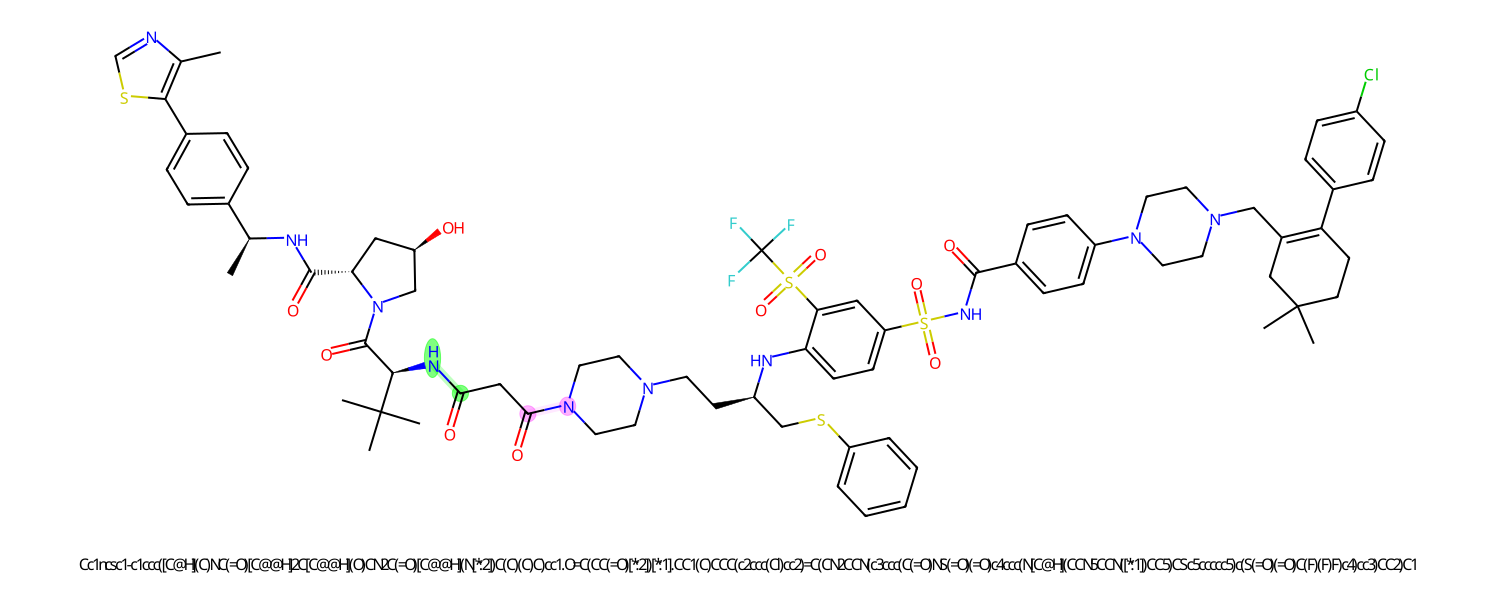

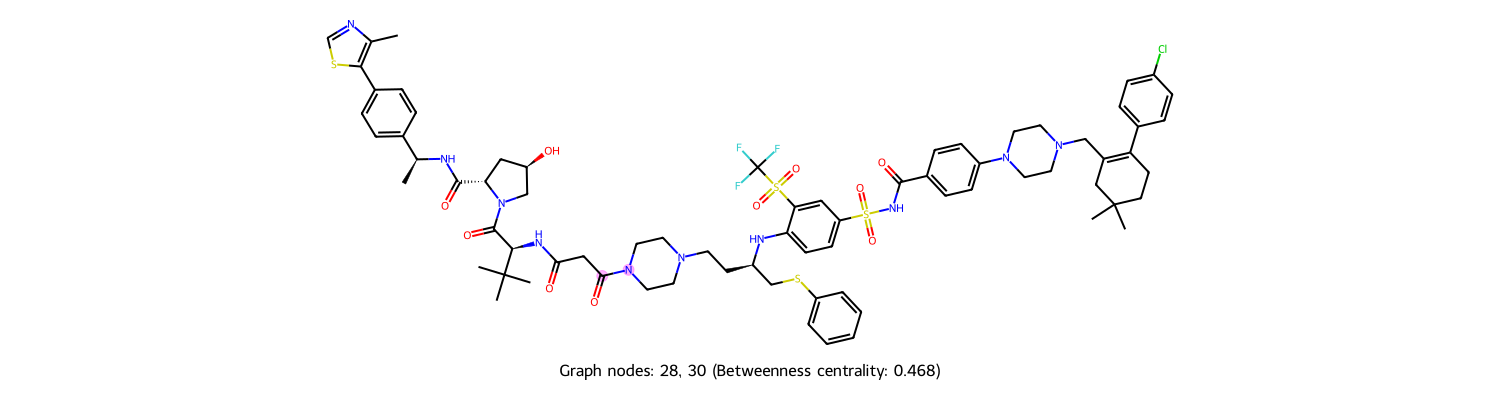

graph_bond_idx                                                                    29
graph_num_nodes                                                                  101
graph_num_edges                                                                  110
graph_betweenness                                                           0.468224
graph_degree                                                                       4
graph_degree_r2                                                                    3
graph_degree_r3                                                                    4
graph_node_u_degree                                                                3
graph_node_u_degree_r2                                                             3
graph_node_u_degree_r3                                                             4
graph_node_v_degree                                                                3
graph_node_v_degree_r2                                           

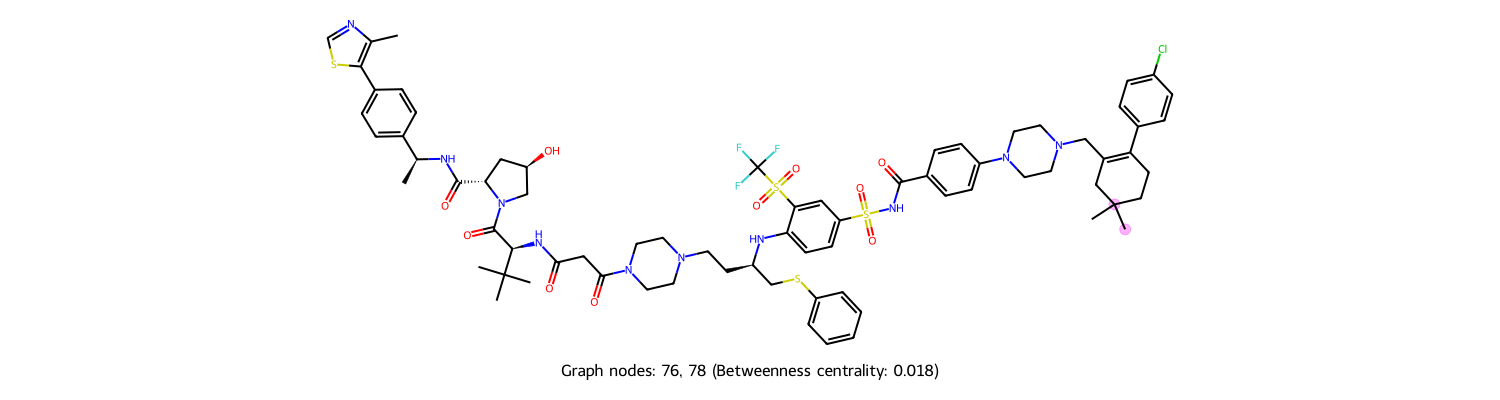

graph_bond_idx                                                                    77
graph_num_nodes                                                                  101
graph_num_edges                                                                  110
graph_betweenness                                                           0.018182
graph_degree                                                                       3
graph_degree_r2                                                                    2
graph_degree_r3                                                                    3
graph_node_u_degree                                                                4
graph_node_u_degree_r2                                                             2
graph_node_u_degree_r3                                                             2
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

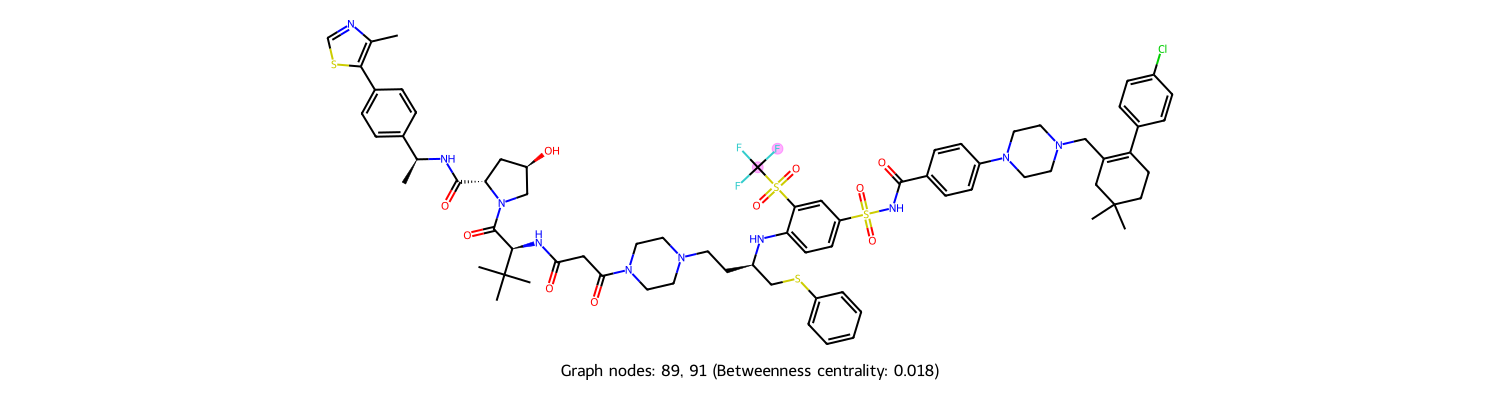

graph_bond_idx                                                                    90
graph_num_nodes                                                                  101
graph_num_edges                                                                  110
graph_betweenness                                                           0.018182
graph_degree                                                                       3
graph_degree_r2                                                                    3
graph_degree_r3                                                                    2
graph_node_u_degree                                                                4
graph_node_u_degree_r2                                                             3
graph_node_u_degree_r3                                                             2
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

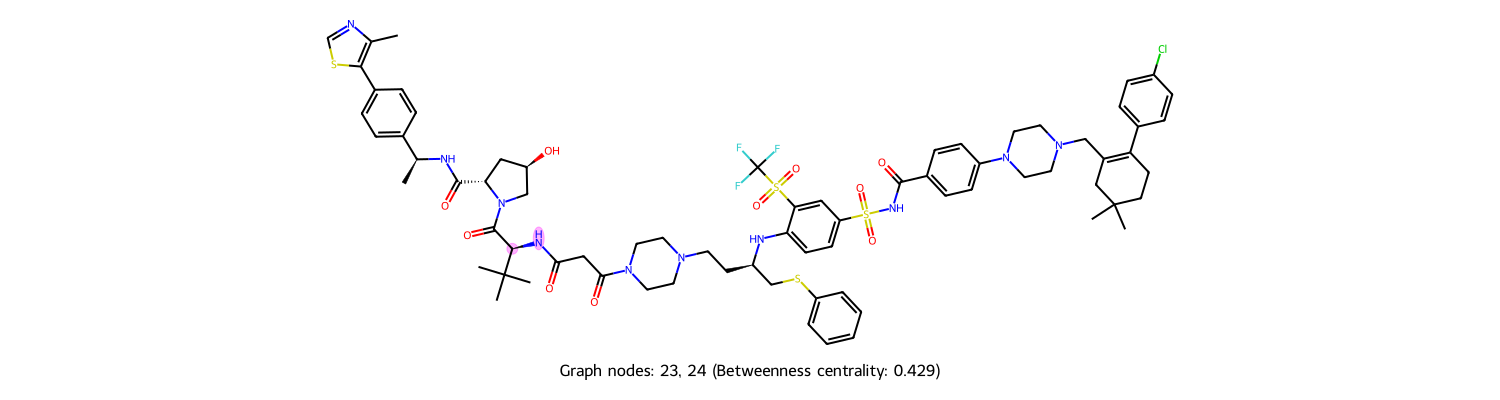

graph_bond_idx                                                                    23
graph_num_nodes                                                                  101
graph_num_edges                                                                  110
graph_betweenness                                                           0.429191
graph_degree                                                                       3
graph_degree_r2                                                                    7
graph_degree_r3                                                                    3
graph_node_u_degree                                                                3
graph_node_u_degree_r2                                                             6
graph_node_u_degree_r3                                                             4
graph_node_v_degree                                                                2
graph_node_v_degree_r2                                           

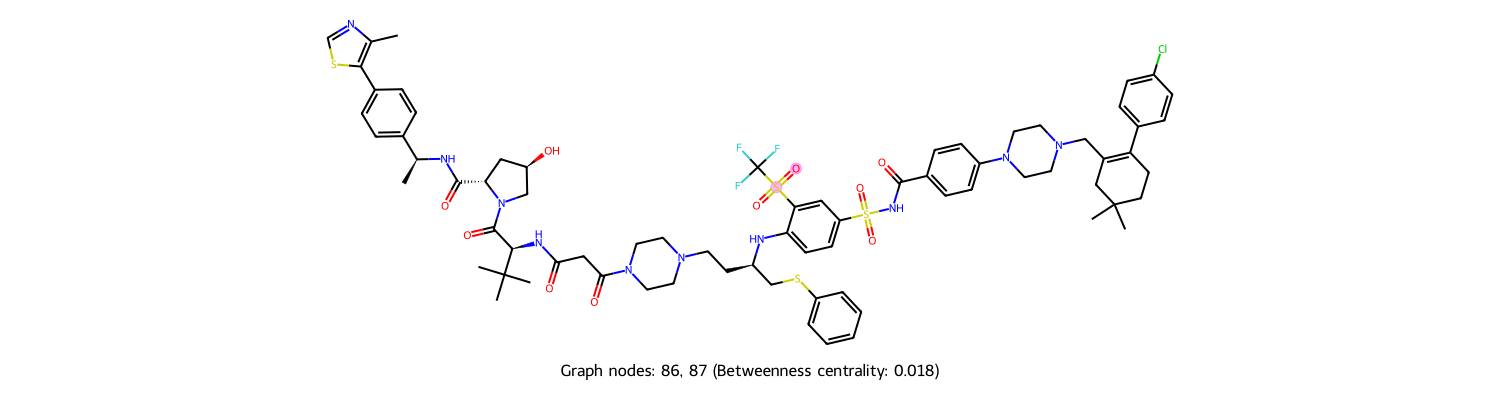

Extracting edge features:  50%|█████     | 1/2 [00:00<00:00,  2.79it/s]

graph_bond_idx                                                                    86
graph_num_nodes                                                                  101
graph_num_edges                                                                  110
graph_betweenness                                                           0.018182
graph_degree                                                                       3
graph_degree_r2                                                                    5
graph_degree_r3                                                                    3
graph_node_u_degree                                                                4
graph_node_u_degree_r2                                                             5
graph_node_u_degree_r3                                                             3
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

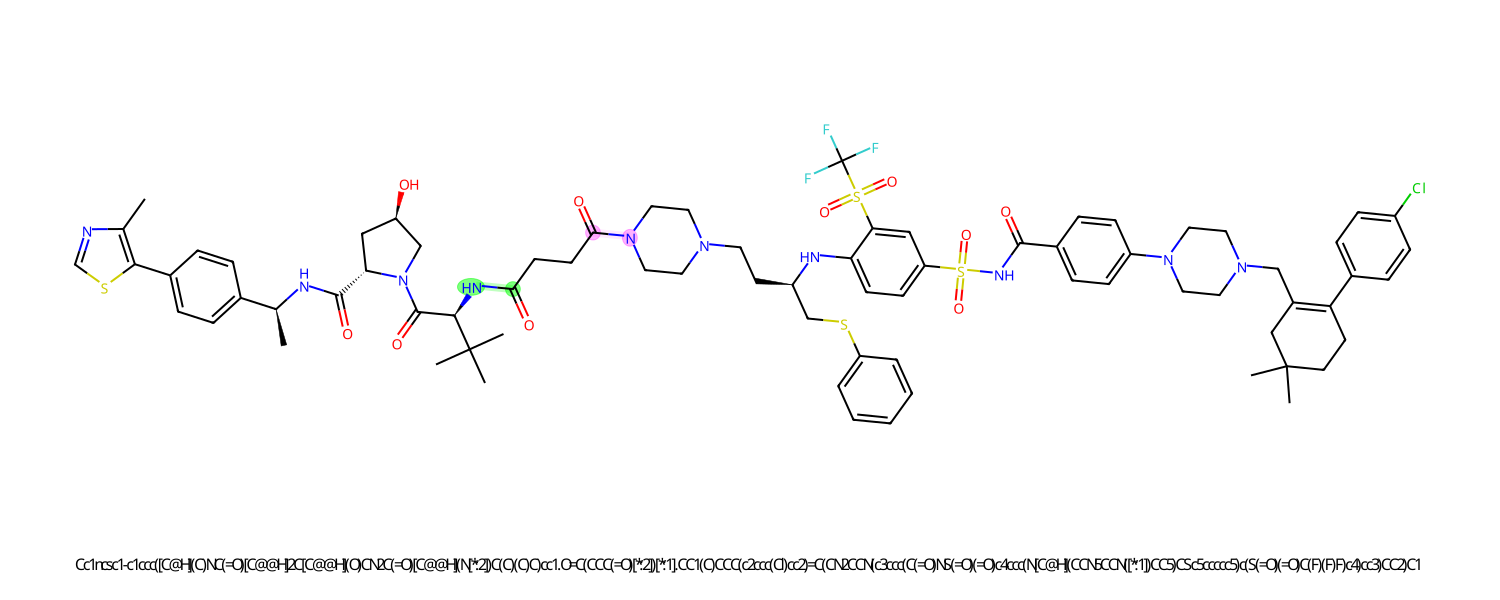

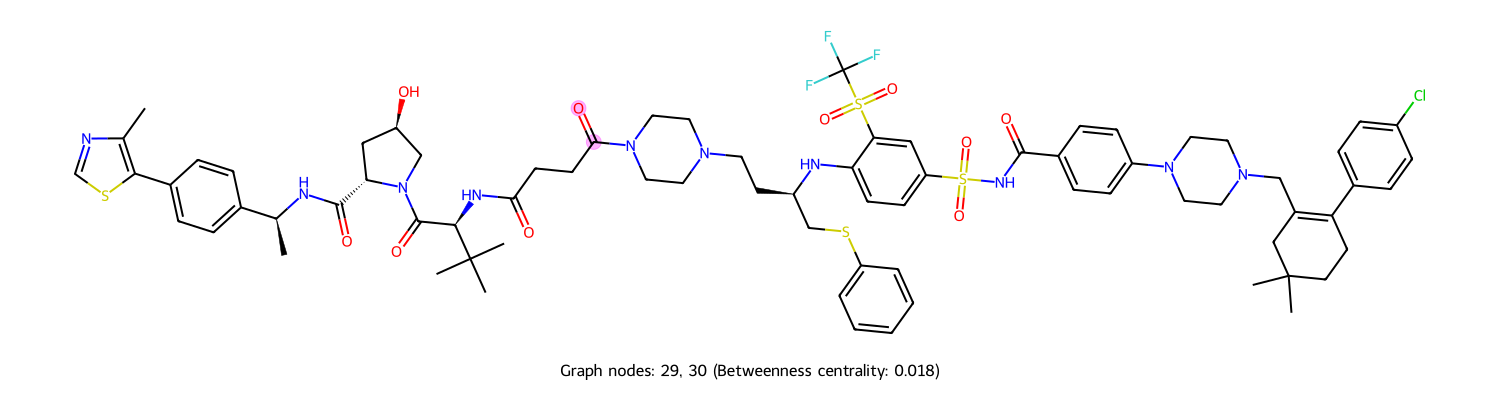

graph_bond_idx                                                                    29
graph_num_nodes                                                                  102
graph_num_edges                                                                  111
graph_betweenness                                                           0.018018
graph_degree                                                                       2
graph_degree_r2                                                                    3
graph_degree_r3                                                                    3
graph_node_u_degree                                                                3
graph_node_u_degree_r2                                                             3
graph_node_u_degree_r3                                                             3
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

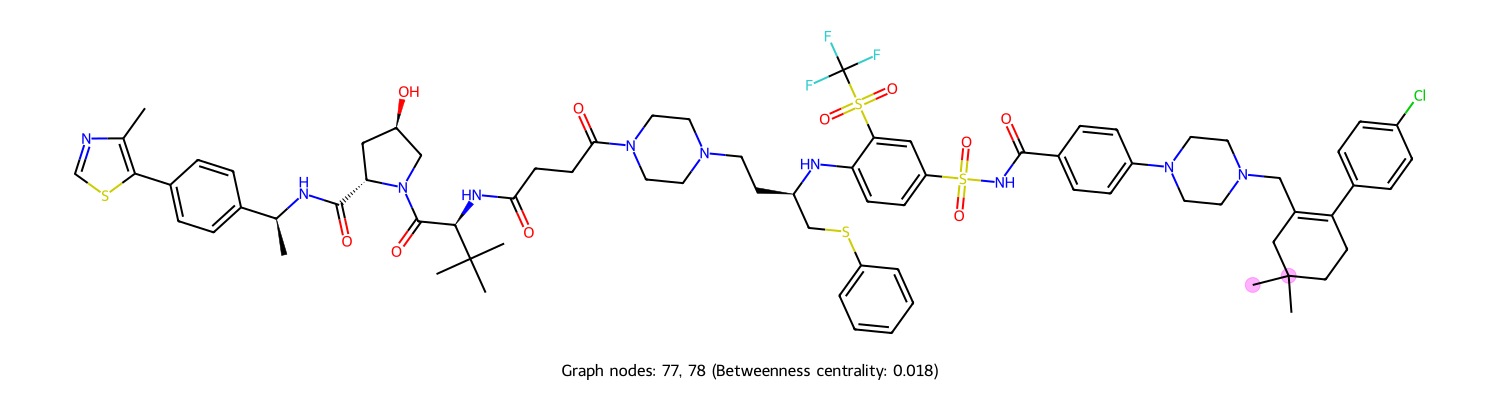

graph_bond_idx                                                                    77
graph_num_nodes                                                                  102
graph_num_edges                                                                  111
graph_betweenness                                                           0.018018
graph_degree                                                                       3
graph_degree_r2                                                                    2
graph_degree_r3                                                                    3
graph_node_u_degree                                                                4
graph_node_u_degree_r2                                                             2
graph_node_u_degree_r3                                                             2
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

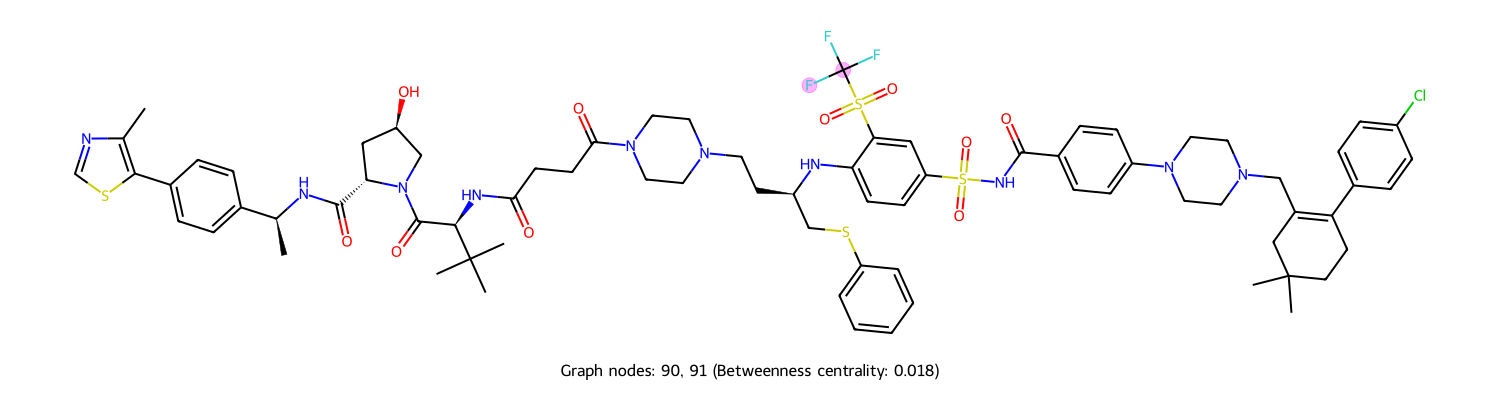

graph_bond_idx                                                                    90
graph_num_nodes                                                                  102
graph_num_edges                                                                  111
graph_betweenness                                                           0.018018
graph_degree                                                                       3
graph_degree_r2                                                                    3
graph_degree_r3                                                                    2
graph_node_u_degree                                                                4
graph_node_u_degree_r2                                                             3
graph_node_u_degree_r3                                                             2
graph_node_v_degree                                                                1
graph_node_v_degree_r2                                           

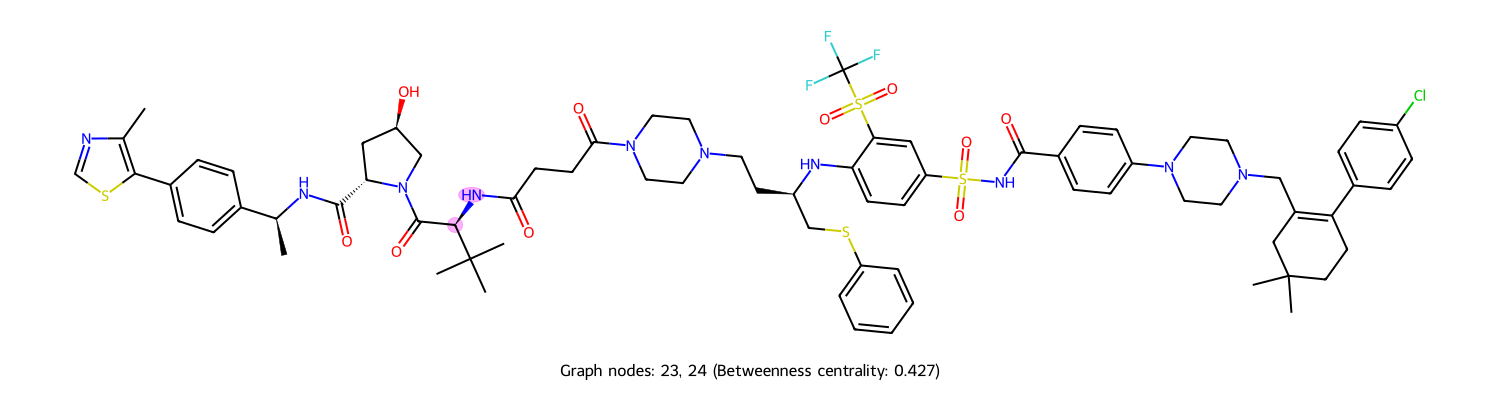

graph_bond_idx                                                                    23
graph_num_nodes                                                                  102
graph_num_edges                                                                  111
graph_betweenness                                                           0.426863
graph_degree                                                                       3
graph_degree_r2                                                                    7
graph_degree_r3                                                                    3
graph_node_u_degree                                                                3
graph_node_u_degree_r2                                                             6
graph_node_u_degree_r3                                                             4
graph_node_v_degree                                                                2
graph_node_v_degree_r2                                           

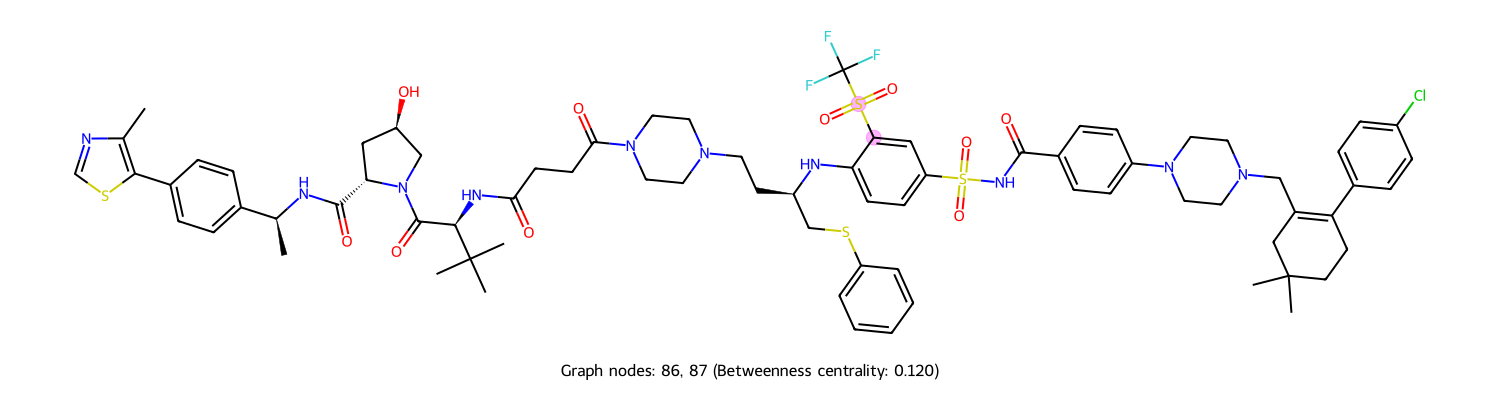

Extracting edge features: 100%|██████████| 2/2 [00:00<00:00,  2.80it/s]

graph_bond_idx                                                                    86
graph_num_nodes                                                                  102
graph_num_edges                                                                  111
graph_betweenness                                                           0.120229
graph_degree                                                                       5
graph_degree_r2                                                                    6
graph_degree_r3                                                                    4
graph_node_u_degree                                                                3
graph_node_u_degree_r2                                                             6
graph_node_u_degree_r3                                                             6
graph_node_v_degree                                                                4
graph_node_v_degree_r2                                           

In [71]:
from typing import Tuple, List

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import networkx as nx
import pandas as pd
import numpy as np

from protac_splitter.chemoinformatics import get_atom_idx_at_attachment


def extract_edge_features(
    protac_smiles: str,
    e3_split_pair: Tuple[int, int] = None,
    wh_split_pair: Tuple[int, int] = None,
    n_bits: int = 512,
    radius: int = 6,
    descriptor_names: List[str] = None,
    fp_as_string: bool = False,
) -> pd.DataFrame:
    """Extract features from the edges of a PROTAC molecule represented as a SMILES string.
    
    Parameters:
        protac_smiles (str): SMILES representation of the PROTAC molecule.
        e3_split_pair (Tuple[int, int]): Indices of the E3 split pair.
        wh_split_pair (Tuple[int, int]): Indices of the warhead split pair.
        n_bits (int): Number of bits for Morgan fingerprints.
        radius (int): Radius for Morgan fingerprints.
        descriptor_names (List[str]): List of RDKit descriptor names to compute.
        
    Returns:
        pd.DataFrame: DataFrame containing edge features.
    """
    mol = Chem.MolFromSmiles(protac_smiles)
    if mol is None:
        raise ValueError(f"Input SMILES could not be parsed: {protac_smiles}")
    # Canonicalize the SMILES
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol, canonical=True))
    if mol is None:
        raise ValueError(f"Input SMILES could not be canonicalized: {protac_smiles}")

    # Step 1: Convert SMILES to NetworkX
    G = nx.Graph()
    # for atom in mol.GetAtoms():
    #     G.add_node(atom.GetIdx())
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
    
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    # Step 2: Create line graph and compute betweenness + degree
    LG = nx.line_graph(G)
    line_betweenness = nx.betweenness_centrality(LG, endpoints=True)
    betweenness = nx.betweenness_centrality(G, endpoints=True)

    # Compute k-hop degrees (number of nodes within 2, 3 hops)
    # TODO: Shall I get the degree of the node in the line graph or the original graph?
    line_degree = dict(LG.degree())
    line_degree_r2 = {}
    line_degree_r3 = {}
    for node in LG.nodes():
        # Nodes within radius 2 and 3 (excluding the center node)
        neighbors_r2 = nx.single_source_shortest_path_length(LG, node, cutoff=2)
        neighbors_r3 = nx.single_source_shortest_path_length(LG, node, cutoff=3)
        line_degree_r2[node] = len([n for n, d in neighbors_r2.items() if d == 2])
        line_degree_r3[node] = len([n for n, d in neighbors_r3.items() if d == 3])

    degree = dict(G.degree())
    degree_r2 = {}
    degree_r3 = {}
    for node in G.nodes():
        # Nodes within radius 2 and 3 (excluding the center node)
        neighbors_r2 = nx.single_source_shortest_path_length(G, node, cutoff=2)
        neighbors_r3 = nx.single_source_shortest_path_length(G, node, cutoff=3)
        degree_r2[node] = len([n for n, d in neighbors_r2.items() if d == 2])
        degree_r3[node] = len([n for n, d in neighbors_r3.items() if d == 3])

    if e3_split_pair is not None and wh_split_pair is not None:
        true_split_edges = {frozenset(e3_split_pair), frozenset(wh_split_pair)}

    # Get molecular characteristics, i.e., Morgan fingerprints and descriptors
    # Generate Morgan fingerprint
    fp_bitvec = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    fp = np.zeros((n_bits,), dtype=np.float32)
    AllChem.DataStructs.ConvertToNumpyArray(fp_bitvec, fp)
    if fp_as_string:
        fp = {"chem_mol_fp": "".join([str(int(bit)) for bit in fp])}
    else:
        fp = {f"chem_mol_fp_{i}": bool(fp[i]) for i in range(n_bits)}
    # Generate RDKit descriptors
    descriptor_func_names = descriptor_names or [
        "MolWt", "HeavyAtomCount", "NumHAcceptors", "NumHDonors",
        "TPSA", "NumRotatableBonds", "RingCount", "MolLogP"
    ]
    functions = [getattr(Descriptors, name) for name in descriptor_func_names]
    descriptors = {f"chem_mol_desc_{name}": func(mol) for name, func in zip(descriptor_func_names, functions)}

    # Step 3: Gather edge features
    # NOTE: Only consider bridge nodes
    edge_features = []
    for (u, v) in nx.bridges(G):
        bond = mol.GetBondBetweenAtoms(u, v)

        # Avoid reporting the same edge twice (i.e., swap u and v if needed) and
        # ensure to find the node pair in the line graph
        node = (u, v) if (u, v) in LG else (v, u)
        node_key = node if node in line_betweenness else (v, u)

        features = {
            "graph_bond_idx": bond.GetIdx(),
            "graph_num_nodes": num_nodes,
            "graph_num_edges": num_edges,
            "graph_betweenness": line_betweenness.get(node_key, 0.0),
            "graph_degree": line_degree.get(node_key, 0),
            "graph_degree_r2": line_degree_r2.get(node_key, 0),
            "graph_degree_r3": line_degree_r3.get(node_key, 0),
            "graph_node_u_degree": degree.get(u, 0),
            "graph_node_u_degree_r2": degree_r2.get(u, 0),
            "graph_node_u_degree_r3": degree_r3.get(u, 0),
            "graph_node_v_degree": degree.get(v, 0),
            "graph_node_v_degree_r2": degree_r2.get(v, 0),
            "graph_node_v_degree_r3": degree_r3.get(v, 0),
            "graph_node_u_betweenness": betweenness.get(u, 0.0),
            "graph_node_v_betweenness": betweenness.get(v, 0.0),
            "chem_bond_type": str(bond.GetBondType()),
            "chem_atom_u": mol.GetAtomWithIdx(u).GetSymbol(),
            "chem_atom_v": mol.GetAtomWithIdx(v).GetSymbol(),
            "chem_is_aromatic": bond.GetIsAromatic(),
            "chem_is_in_ring": bond.IsInRing(),
            "chem_mol_smiles": protac_smiles,
            "chem_mol_n_bits": n_bits,
            "chem_mol_radius": radius,
        }
        # Add RDKit descriptors and Morgan fingerprint
        features.update(fp)
        features.update(descriptors)

        # Add E3 and warhead split labels
        if e3_split_pair is not None and wh_split_pair is not None:
            features.update({
                "label_is_split": frozenset([u, v]) in true_split_edges,
                "label_e3_split": frozenset([u, v]) == frozenset(e3_split_pair),
                "label_wh_split": frozenset([u, v]) == frozenset(wh_split_pair),
            })

        # Append the features to the list of edge features
        edge_features.append(features)

    df = pd.DataFrame(edge_features)

    # Identify columns with int64 dtype
    int64_cols = df.select_dtypes(include=['int64']).columns

    # Create a dictionary mapping these columns to int32
    dtype_mapping = {col: np.int32 for col in int64_cols}

    # Apply the type conversion
    df = df.astype(dtype_mapping)
    
    return df

def get_edge_features(
    protac_smiles: str | List[str],
    wh_smiles: str | List[str],
    lk_smiles: str | List[str],
    e3_smiles: str | List[str],
    n_bits: int = 512,
    radius: int = 6,
    descriptor_names: List[str] = None,
    fp_as_string: bool = False,
    verbose: int = 0,
) -> pd.DataFrame:
    """Get edge features for a given PROTAC molecule and its components.
    
    Parameters:
        protac_smiles (str | List[str]): SMILES representation of the PROTAC molecule.
        wh_smiles (str | List[str]): SMILES representation of the warhead.
        lk_smiles (str | List[str]): SMILES representation of the linker.
        e3_smiles (str | List[str]): SMILES representation of the E3 binder.
        n_bits (int): Number of bits for Morgan fingerprints.
        radius (int): Radius for Morgan fingerprints.
        descriptor_names (List[str]): List of RDKit descriptor names to compute.
        
    Returns:
        pd.DataFrame: DataFrame containing edge features.
    """
    if isinstance(protac_smiles, str):
        protac_smiles = [protac_smiles]
    if isinstance(wh_smiles, str):
        wh_smiles = [wh_smiles]
    if isinstance(lk_smiles, str):
        lk_smiles = [lk_smiles]
    if isinstance(e3_smiles, str):
        e3_smiles = [e3_smiles]

    iterables = zip(protac_smiles, wh_smiles, lk_smiles, e3_smiles)
    iterables = tqdm(iterables, desc="Extracting edge features", total=len(protac_smiles), disable=verbose == 0)
    features_list = []
    for protac_smi, wh_smi, lk_smi, e3_smi in iterables:
        if verbose > 1:
            get_mapped_protac_img(protac_smi, wh_smi, lk_smi, e3_smi, w=1500, h=600, display_image=True, useSVG=True)

        # Convert SMILES to RDKit molecules
        protac = Chem.MolFromSmiles(protac_smi)
        wh = Chem.MolFromSmiles(wh_smi)
        lk = Chem.MolFromSmiles(lk_smi)
        e3 = Chem.MolFromSmiles(e3_smi)
        if protac is None or wh is None or lk is None or e3 is None:
            raise ValueError(f"Invalid SMILES string: {protac}, {wh}, {lk}, {e3}")

        # Get the attachment points
        wh_edge = get_atom_idx_at_attachment(protac, wh, lk)
        e3_edge = get_atom_idx_at_attachment(protac, e3, lk)

        # Extract features
        features = extract_edge_features(
            protac_smi,
            e3_split_pair=e3_edge,
            wh_split_pair=wh_edge,
            n_bits=n_bits,
            radius=radius,
            descriptor_names=descriptor_names,
            fp_as_string=fp_as_string,
        )

        if verbose > 1:
            # Randomly sample and display 5 edges
            sample_edges = features.sample(n=5, random_state=42)
            # Display the sampled edges
            for _, row in sample_edges.iterrows():
                bond = protac.GetBondWithIdx(row['graph_bond_idx'])
                u, v = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                display(Draw.MolToImage(
                    protac,
                    size=(1500, 400),
                    highlightColor=(1, 0, 1, 0.3), # Light purple
                    highlightAtoms=[u, v], # Highlight the two atoms
                    legend=f"Graph nodes: {u}, {v} (Betweenness centrality: {row['graph_betweenness']:.3f})",
                ))
                # print(row[[c for c in features.columns if c.startswith('graph_')] + ['chem_atom_u', 'chem_atom_v', 'chem_is_in_ring']])
                print(row)

        # Append the features to the list
        features_list.append(features)

    return pd.concat(features_list, ignore_index=True)

# Example usage
features = get_edge_features(
    protac_smiles=held_out_df['PROTAC SMILES'].tolist()[:2],
    wh_smiles=held_out_df['POI Ligand SMILES with direction'].tolist()[:2],
    lk_smiles=held_out_df['Linker SMILES with direction'].tolist()[:2],
    e3_smiles=held_out_df['E3 Binder SMILES with direction'].tolist()[:2],
    n_bits=512,
    radius=6,
    fp_as_string=True,
    verbose=2,
)

In [56]:
print(features[[c for c in features.columns if c != 'chem_smiles']].head(5).to_markdown(index=False))

|   graph_bond_idx |   graph_num_nodes |   graph_num_edges |   graph_betweenness |   graph_degree |   graph_degree_r2 |   graph_degree_r3 |   graph_node_u_degree |   graph_node_u_degree_r2 |   graph_node_u_degree_r3 |   graph_node_v_degree |   graph_node_v_degree_r2 |   graph_node_v_degree_r3 | chem_bond_type   | chem_atom_u   | chem_atom_v   | chem_is_aromatic   | chem_is_in_ring   |   chem_mol_n_bits |   chem_mol_radius |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      chem_mol_fp |   chem_mol_desc_MolWt |   chem_mol_desc_HeavyAtomCount | 

In [60]:
features = get_edge_features(
    protac_smiles=held_out_df['PROTAC SMILES'].tolist()[:100],
    wh_smiles=held_out_df['POI Ligand SMILES with direction'].tolist()[:100],
    lk_smiles=held_out_df['Linker SMILES with direction'].tolist()[:100],
    e3_smiles=held_out_df['E3 Binder SMILES with direction'].tolist()[:100],
    n_bits=512,
    radius=6,
    fp_as_string=True,
    verbose=1,
)
features['label_is_split'].value_counts()

Extracting edge features: 100%|██████████| 100/100 [00:01<00:00, 90.40it/s]


label_is_split
False    4110
True      200
Name: count, dtype: int64

### Data Preprocessing

In [40]:
from datasets import load_dataset

def get_substructs(row):
    text = row["text"]
    labels = row["labels"]
    return {
        "PROTAC SMILES": text,
        "POI Ligand SMILES with direction": labels.split(".")[2],
        "Linker SMILES with direction": labels.split(".")[1],
        "E3 Binder SMILES with direction": labels.split(".")[0],
    }

ds = load_dataset("ailab-bio/PROTAC-Splitter-Dataset", "clustered")
ds = ds.map(get_substructs, num_proc=8, remove_columns=["text", "labels"])

In [ ]:
tmp = ds["train"].select(range(100)).map(
    lambda x: get_edge_features(
        protac_smiles=x["PROTAC SMILES"],
        wh_smiles=x["POI Ligand SMILES with direction"],
        lk_smiles=x["Linker SMILES with direction"],
        e3_smiles=x["E3 Binder SMILES with direction"],
        n_bits=512,
        radius=6,
        verbose=0,
    ),
    num_proc=8,
    batched=True,
    remove_columns=ds["train"].column_names,
)
tmp

ds = ds.map(
    lambda x: get_edge_features(
        protac_smiles=x["PROTAC SMILES"],
        wh_smiles=x["POI Ligand SMILES with direction"],
        lk_smiles=x["Linker SMILES with direction"],
        e3_smiles=x["E3 Binder SMILES with direction"],
        n_bits=512,
        radius=6,
        verbose=0,
    ),
    num_proc=8,
    batched=True,
    remove_columns=["PROTAC SMILES", "POI Ligand SMILES with direction", "Linker SMILES with direction", "E3 Binder SMILES with direction"],
)

Map (num_proc=8):   0%|          | 0/1297604 [00:00<?, ? examples/s]

In [ ]:
ds

In [ ]:
# Upload the dataset to Hugging Face
ds.push_to_hub("ailab-bio/PROTAC-Splitter-Graph-Dataset", private=True)

In [37]:
# graph_train_df = []
# train_size = 2000
# samples = train_df.sample(n=train_size, random_state=42)
# for i in tqdm(range(train_size)):
#     sample = samples.iloc[i]
#     protac_smiles = sample['PROTAC SMILES']
#     wh_smiles = sample['POI Ligand SMILES with direction']
#     lk_smiles = sample['Linker SMILES with direction']
#     e3_smiles = sample['E3 Binder SMILES with direction']

#     protac = Chem.MolFromSmiles(protac_smiles)
#     wh = Chem.MolFromSmiles(wh_smiles)
#     lk = Chem.MolFromSmiles(lk_smiles)
#     e3 = Chem.MolFromSmiles(e3_smiles)

#     wh_edge = get_atom_idx_at_attachment(protac, wh, lk)
#     e3_edge = get_atom_idx_at_attachment(protac, e3, lk)
#     if wh_edge is None or e3_edge is None:
#         continue

#     features = extract_edge_features(protac_smiles, e3_edge, wh_edge)
#     # Remove all rows that are not bridges, i.e, with "graph_is_bridge" == 0
#     features = features[features['graph_is_bridge'] == 1]
#     # Remove the "graph_is_bridge" column
#     features = features.drop(columns=['graph_is_bridge'])
#     graph_train_df.append(features)
# graph_train_df = pd.concat(graph_train_df, ignore_index=True)

graph_train_df = get_edge_features(
    protac_smiles=train_df['PROTAC SMILES'].tolist(),
    wh_smiles=train_df['POI Ligand SMILES with direction'].tolist(),
    lk_smiles=train_df['Linker SMILES with direction'].tolist(),
    e3_smiles=train_df['E3 Binder SMILES with direction'].tolist(),
    n_bits=512,
    radius=6,
    verbose=1,
)
print(f'Number of edges in the training set: {len(graph_train_df):,}')

Extracting edge features:   0%|          | 3443/1298401 [00:57<6:01:42, 59.67it/s] 


KeyboardInterrupt: 

In [184]:
graph_test_df = []
test_size = 1000
samples = held_out_df.sample(n=test_size, random_state=42)
for i in tqdm(range(test_size)):
    sample = samples.iloc[i]
    protac_smiles = sample['PROTAC SMILES']
    wh_smiles = sample['POI Ligand SMILES with direction']
    lk_smiles = sample['Linker SMILES with direction']
    e3_smiles = sample['E3 Binder SMILES with direction']
    protac = Chem.MolFromSmiles(protac_smiles)
    wh = Chem.MolFromSmiles(wh_smiles)
    lk = Chem.MolFromSmiles(lk_smiles)
    e3 = Chem.MolFromSmiles(e3_smiles)
    wh_edge = get_atom_idx_at_attachment(protac, wh, lk)
    e3_edge = get_atom_idx_at_attachment(protac, e3, lk)
    if wh_edge is None or e3_edge is None:
        continue
    features = extract_edge_features(protac_smiles, e3_edge, wh_edge)
    # Remove all rows that are not bridges, i.e, with "graph_is_bridge" == 0
    features = features[features['graph_is_bridge'] == 1]
    # Remove the "graph_is_bridge" column
    features = features.drop(columns=['graph_is_bridge'])
    graph_test_df.append(features)
graph_test_df = pd.concat(graph_test_df, ignore_index=True)
print(f'Number of edges in the test set: {len(graph_test_df):,}')

100%|██████████| 1000/1000 [00:08<00:00, 117.08it/s]

Number of edges in the test set: 34,945


In [185]:
graph_train_df = graph_train_df[(graph_train_df["label_e3_split"] + graph_train_df["label_wh_split"]) <= 1]
graph_test_df = graph_test_df[(graph_test_df["label_e3_split"] + graph_test_df["label_wh_split"]) <= 1]
print(f"Graph train set size: {len(graph_train_df):,}")
print(f"Graph test set size: {len(graph_test_df):,}")

Graph train set size: 79,565
Graph test set size: 34,941


In [202]:
print(graph_train_df.columns.duplicated().sum())
print(graph_test_df.columns.duplicated().sum())

graph_train_df = graph_train_df.drop_duplicates()
graph_test_df = graph_test_df.drop_duplicates()

0
0


In [209]:
graph_train_df[["chem_is_aromatic", "chem_is_in_ring"]].value_counts().T

chem_is_aromatic  chem_is_in_ring
False             False              79565
Name: count, dtype: int64

In [210]:
# Define feature groups
graph_features = [
    # "graph_bond_idx",
    "graph_num_nodes",
    "graph_num_edges",
    "graph_betweenness",
    "graph_degree",
    "graph_degree_r2",
    "graph_degree_r3",
]

chem_features = [
    "chem_bond_type",
    "chem_atom_u",
    "chem_atom_v",
    "chem_is_aromatic",
    "chem_is_in_ring",
]

# Preprocessing
numeric_features = graph_features
categorical_features = ["chem_bond_type", "chem_atom_u", "chem_atom_v"]
boolean_features = ["chem_is_aromatic", "chem_is_in_ring"]
descriptor_features = desc_columns # e.g., ['desc_MolWt', ...]
fingerprint_features = fp_columns  # e.g., ['fp_0', ..., 'fp_2047']

### PCA

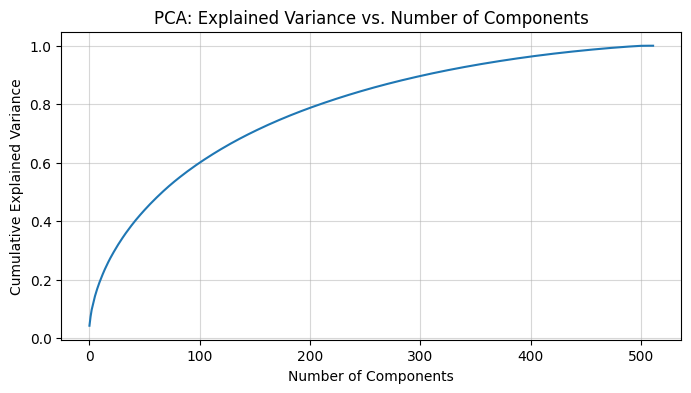

Number of components to explain 95% variance: 378


In [214]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Graph-only transformer
graph_transformer = ColumnTransformer([
    ("num", "passthrough", numeric_features),
])

# Full transformer
full_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
    ("desc", StandardScaler(), descriptor_features),
    ("fp", "passthrough", fingerprint_features),
])

# Combine descriptor and fingerprint columns for PCA
pca_features = numeric_features + boolean_features + descriptor_features + fingerprint_features + categorical_features
pca_features = fingerprint_features

# Drop rows with NaN in these columns (if any)
X_pca = graph_train_df[pca_features].dropna()

# Run PCA
pca = PCA(random_state=42)
pca.fit(X_pca)
# pca.fit(full_transformer.fit_transform(X_pca))

# Plot explained variance ratio
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs. Number of Components')
plt.grid(alpha=0.5)
plt.show()

print(f"Number of components to explain 95% variance: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1}")

In [190]:
# # Get the number of components to explain 95% variance
# n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
# # Isolate the PCA components
# pca_components = pca.transform(full_transformer.fit_transform(graph_train_df[pca_features]))[:, :n_components_95]
# pca_components.shape

In [215]:
# Get the number of components that explain X% of the variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
for threshold in [0.90, 0.95, 0.99, 0.999, 0.9999]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Number of components explaining {threshold*100:.2f}% of the variance: {n_components}")

Number of components explaining 90.00% of the variance: 306
Number of components explaining 95.00% of the variance: 378
Number of components explaining 99.00% of the variance: 467
Number of components explaining 99.90% of the variance: 498
Number of components explaining 99.99% of the variance: 505


### Pipelines

#### Binary Classification: Split vs. No Split

In [192]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd
from xgboost import XGBClassifier

# Graph-only transformer
graph_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
])

# Full transformer
full_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("bool", "passthrough", boolean_features),
    ("desc", StandardScaler(), descriptor_features),
    ("fp", "passthrough", fingerprint_features),
])

# Define classifiers
classifier = XGBClassifier(
    random_state=42,
    tree_method="hist" # faster histogram-based grow
)
# classifier = LogisticRegression(random_state=42)

# Pipelines
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("clf", classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("clf", classifier)
])

# Get the training and test sets
X_train = graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = graph_train_df["label_is_split"]

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = graph_test_df["label_is_split"]

# Train and evaluate
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     32949
           1       0.73      0.34      0.46      1992

    accuracy                           0.95     34941
   macro avg       0.84      0.66      0.72     34941
weighted avg       0.95      0.95      0.95     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     32949
           1       0.78      0.49      0.60      1992

    accuracy                           0.96     34941
   macro avg       0.88      0.74      0.79     34941
weighted avg       0.96      0.96      0.96     34941



In [244]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # NOTE: from imblearn!
from sklearn.linear_model import LogisticRegression

# Graph-only transformer
graph_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
])

# Full transformer
full_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
    ("desc", StandardScaler(), descriptor_features),
    # ("fp", "passthrough", fingerprint_features),
    ("fp", make_pipeline(TruncatedSVD(n_components=378, random_state=42)), fp_columns)
])

# Define classifiers
graph_classifier = XGBClassifier(
    random_state=42,
    tree_method="hist" # faster histogram-based grow
)
classifier = XGBClassifier(
    random_state=42,
    tree_method="hist" # faster histogram-based grow
)
# classifier = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1, C=0.1, solver="saga", class_weight="balanced")

# Pipelines
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", graph_classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

# Get the training and test sets
ds = graph_train_df.sample(frac=1, random_state=42)
X_train = ds.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = ds["label_is_split"]

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = graph_test_df["label_is_split"]

# Train and evaluate
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     32949
           1       0.33      0.77      0.46      1992

    accuracy                           0.90     34941
   macro avg       0.66      0.84      0.70     34941
weighted avg       0.95      0.90      0.92     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     32949
           1       0.62      0.50      0.55      1992

    accuracy                           0.95     34941
   macro avg       0.79      0.74      0.76     34941
weighted avg       0.95      0.95      0.95     34941



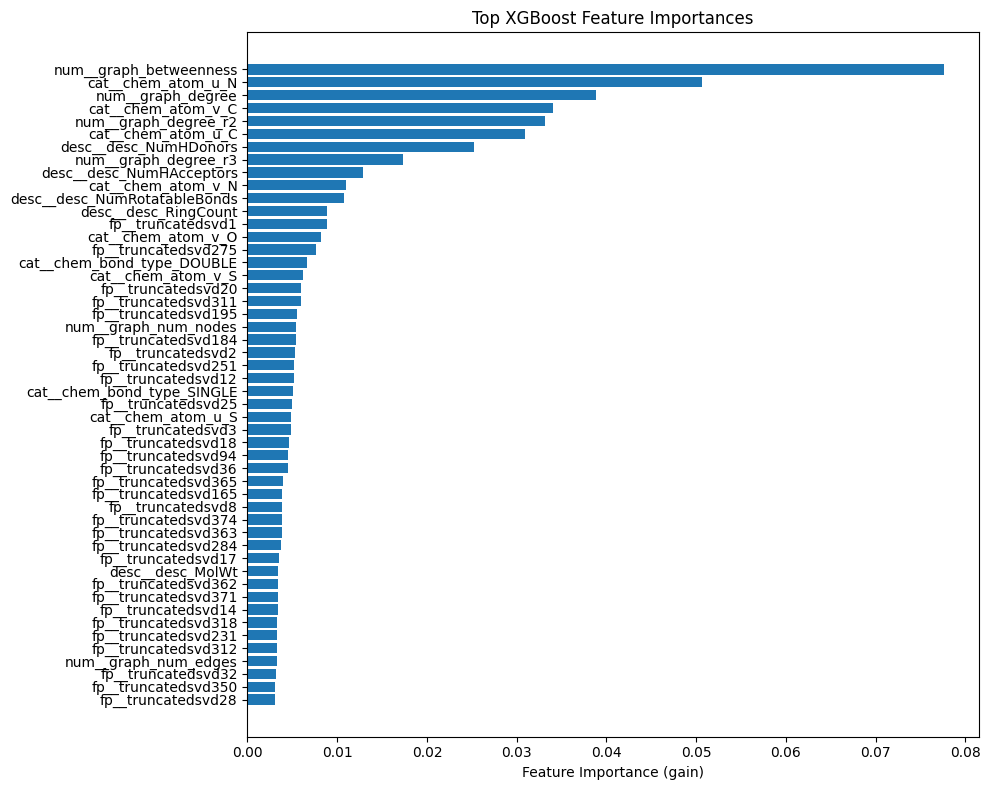

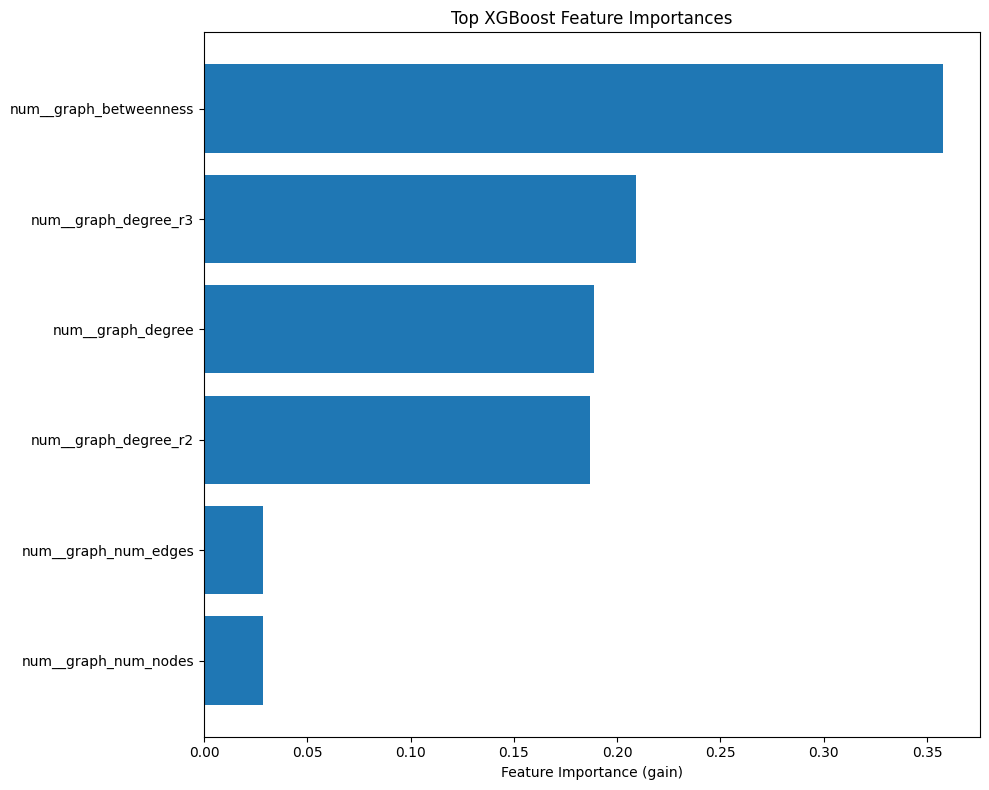

In [247]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_feature_importances(pipe, top_n=10):
    feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
    importances = pipe.named_steps["clf"].feature_importances_

    # Clamp top_n to avoid IndexError
    available_n = min(top_n, len(feature_names), len(importances))
    sorted_idx = np.argsort(importances)[::-1]

    # print(f"Number of features: {len(feature_names)}")
    # print(f"Top {available_n} features:")
    # for i in range(available_n):
    #     print(f"{i + 1}: {feature_names[sorted_idx[i]]} ({importances[sorted_idx[i]]:.4f})")

    plt.figure(figsize=(10, 8))
    plt.barh(
        np.array(feature_names)[sorted_idx[:available_n]][::-1],
        importances[sorted_idx[:available_n]][::-1]
    )
    plt.xlabel("Feature Importance (gain)")
    plt.title("Top XGBoost Feature Importances")
    plt.tight_layout()
    plt.show()

plot_top_feature_importances(full_pipeline, top_n=50)
plot_top_feature_importances(graph_pipeline, top_n=50)

#### Multi-Class Classification: No Split vs. E3 vs. Warhead

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     32949
           1       0.36      0.04      0.07       996
           2       0.83      0.55      0.66       996

    accuracy                           0.96     34941
   macro avg       0.72      0.53      0.57     34941
weighted avg       0.94      0.96      0.94     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     32949
           1       0.49      0.11      0.17       996
           2       0.77      0.61      0.68       996

    accuracy                           0.96     34941
   macro avg       0.74      0.57      0.61     34941
weighted avg       0.94      0.96      0.95     34941



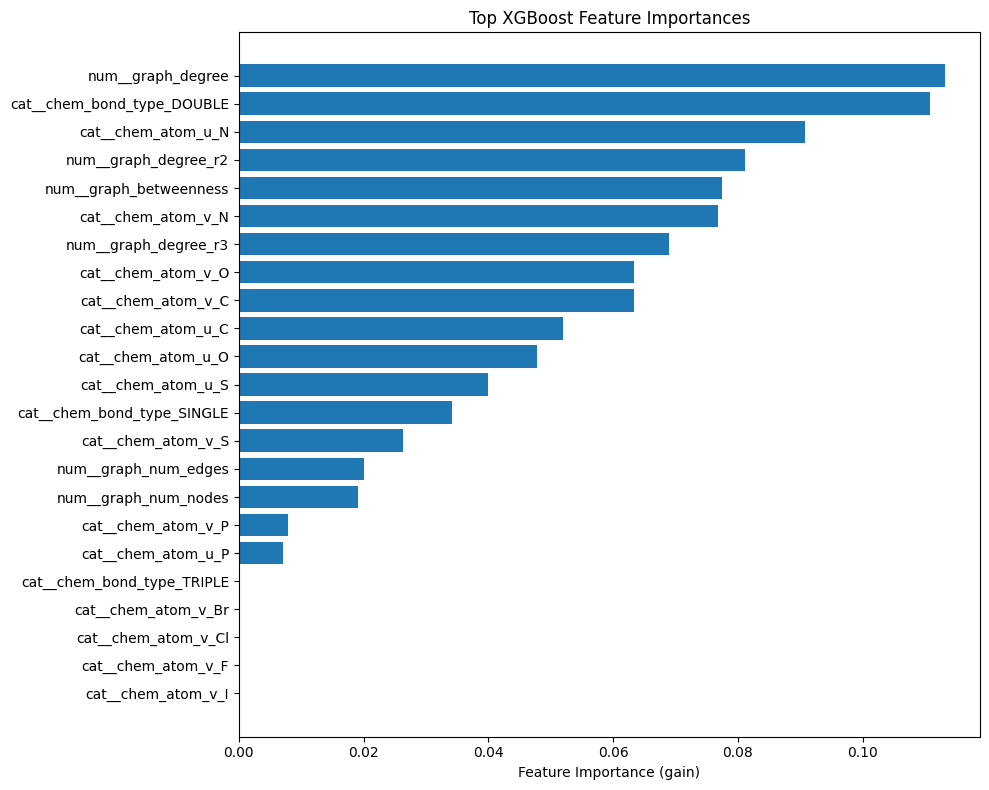

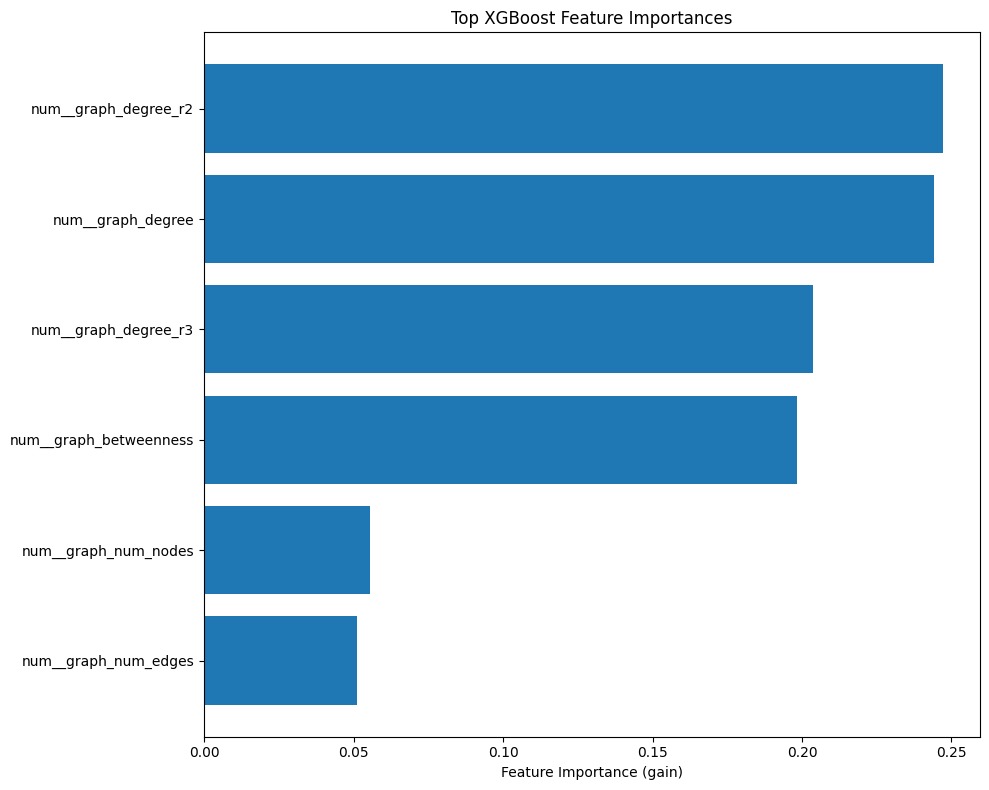

In [249]:
from sklearn.pipeline import Pipeline

def build_multiclass_target(df: pd.DataFrame) -> pd.Series:
    """
    Returns multiclass target: 0 = no split, 1 = E3 split, 2 = WH split
    """
    assert ((df["label_e3_split"] + df["label_wh_split"]) <= 1).all()
    y = (
        df["label_wh_split"] * 1 +
        df["label_e3_split"] * 2
    )
    return y

# Graph-only transformer
graph_transformer = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
])

# Full transformer
full_transformer = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
])

# Define classifiers
graph_classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

# Pipelines
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("clf", graph_classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("clf", classifier)
])

# Assume df is your input DataFrame
X_train = graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(graph_train_df)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# Train and evaluate
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

plot_top_feature_importances(full_pipeline, top_n=50)
plot_top_feature_importances(graph_pipeline, top_n=50)

### Optuna

In [269]:
import pandas as pd
from typing import List, Optional
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import optuna

def build_pipeline(
    graph_features: List[str],
    categorical_features: List[str],
    descriptor_features: Optional[List[str]] = None,
    fingerprint_features: Optional[List[str]] = None,
    use_descriptors: bool = True,
    use_fingerprints: bool = True,
    scaler_graph: str = "passthrough",
    scaler_desc: str = "passthrough",
    use_svd_fp: bool = True,
    n_svd_components: int = 100,
    binary: bool = False,
    smote_k_neighbors: int = 5,
    xgb_params: Optional[dict] = None,
) -> ImbPipeline:
    transformers = [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
    
    if scaler_graph == "standard":
        transformers.append(("num", StandardScaler(), graph_features))
    else:
        transformers.append(("num", "passthrough", graph_features))

    if use_descriptors and descriptor_features:
        desc_block = (
            ("desc", StandardScaler(), descriptor_features)
            if scaler_desc == "standard"
            else ("desc", "passthrough", descriptor_features)
        )
        transformers.append(desc_block)

    if use_fingerprints and fingerprint_features:
        if use_svd_fp:
            fp_block = (
                "fp",
                ("svd", TruncatedSVD(n_components=n_svd_components, random_state=42)),
                fingerprint_features
            )
        else:
            fp_block = ("fp", "passthrough", fingerprint_features)
        transformers.append(fp_block)

    preprocessor = ColumnTransformer(transformers)

    if xgb_params is None:
        xgb_params = {}

    classifier = XGBClassifier(
        random_state=42,
        eval_metric="logloss" if binary else "mlogloss",
        objective="binary:logistic" if binary else "multi:softprob",
        tree_method="hist",
        **xgb_params
    )

    return ImbPipeline([
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42, k_neighbors=smote_k_neighbors)),
        ("clf", classifier)
    ])


def objective(
    trial,
    X_train,
    y_train,
    X_val,
    y_val,
    graph_features,
    categorical_features,
    fingerprint_features,
    binary
):
    # Descriptor subset selection
    descriptor_subsets = [
        ("MolWt", "TPSA"),
        ("MolWt", "HeavyAtomCount", "TPSA"),
        ("MolWt", "HeavyAtomCount", "TPSA", "MolLogP"),
        ("MolWt", "HeavyAtomCount", "NumHAcceptors", "NumHDonors", "TPSA", "NumRotatableBonds", "RingCount", "MolLogP")
    ]
    selected_desc_names = trial.suggest_categorical("desc_subset", descriptor_subsets)
    selected_desc_features = [f"desc_{name}" for name in selected_desc_names]

    use_descriptors = trial.suggest_categorical("use_descriptors", [True, False])
    use_fingerprints = trial.suggest_categorical("use_fingerprints", [True, False])
    scaler_desc = trial.suggest_categorical("scaler_desc", ["passthrough", "standard"])
    scaler_graph = trial.suggest_categorical("scaler_graph", ["passthrough", "standard"])
    use_svd_fp = trial.suggest_categorical("use_svd_fp", [True, False])
    n_svd_components = trial.suggest_int("n_svd_components", 20, 200) if use_svd_fp else 0
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    smote_k_neighbors = trial.suggest_int("smote_k_neighbors", 2, 10)

    xgb_params = {
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
    }

    pipeline = build_pipeline(
        graph_features=graph_features,
        categorical_features=categorical_features,
        descriptor_features=selected_desc_features,
        fingerprint_features=fingerprint_features,
        use_descriptors=use_descriptors,
        use_fingerprints=use_fingerprints,
        scaler_desc=scaler_desc,
        scaler_graph=scaler_graph,
        use_svd_fp=use_svd_fp,
        n_svd_components=n_svd_components if use_svd_fp else None,
        binary=binary,
        smote_k_neighbors=smote_k_neighbors,
        xgb_params=xgb_params
    )

    scoring = "f1" if binary else "f1_macro"
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        error_score="raise"
    )
    return scores.mean()


def run_optuna_optimization(
    X: pd.DataFrame,
    y: pd.Series,
    graph_features: List[str],
    categorical_features: List[str],
    fingerprint_features: List[str],
    binary: bool = False,
    n_trials: int = 30,
    test_size: float = 0.2,
    random_state: int = 42
):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(
        trial,
        X_train,
        y_train,
        X_val,
        y_val,
        graph_features,
        categorical_features,
        fingerprint_features,
        binary
    ), n_trials=n_trials)
    return study

In [267]:
# For multiclass
study = run_optuna_optimization(
    X=graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"]),
    y=build_multiclass_target(graph_train_df),
    graph_features=graph_features,
    categorical_features=categorical_features,
    fingerprint_features=fingerprint_features,
    n_trials=3,
    binary=False
)

print("Best trial:", study.best_trial.value)
print("Best params:", study.best_trial.params)

[I 2025-05-20 13:25:02,828] A new study created in memory with name: no-name-b3406741-e5da-4b4c-a5e6-4227e044ab82
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('MolWt', 'TPSA') which is of type tuple.
  warnings.warn(message)
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('MolWt', 'HeavyAtomCount', 'TPSA') which is of type tuple.
  warnings.warn(message)
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but co

KeyboardInterrupt: 

In [270]:
# For binary
study = run_optuna_optimization(
    X=graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"]),
    y=graph_train_df["label_is_split"],
    graph_features=graph_features,
    categorical_features=categorical_features,
    fingerprint_features=fingerprint_features,
    n_trials=3,
    binary=True
)

print("Best trial:", study.best_trial.value)
print("Best params:", study.best_trial.params)

[I 2025-05-20 13:34:34,190] A new study created in memory with name: no-name-ed71f770-d093-458a-88d2-8dea8b7995b8
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('MolWt', 'TPSA') which is of type tuple.
  warnings.warn(message)
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('MolWt', 'HeavyAtomCount', 'TPSA') which is of type tuple.
  warnings.warn(message)
/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but co

Best trial: 0.5589580393476706
Best params: {'desc_subset': ('MolWt', 'TPSA'), 'use_descriptors': True, 'use_fingerprints': True, 'scaler_desc': 'standard', 'scaler_graph': 'passthrough', 'use_svd_fp': False, 'max_depth': 8, 'learning_rate': 0.0980940141076146, 'n_estimators': 286, 'smote_k_neighbors': 4}


Train and save pipeline with best hyperparameters.

In [272]:
import joblib
from typing import Union
from pathlib import Path

def train_and_save_best_pipeline(
    X: pd.DataFrame,
    y: pd.Series,
    study,
    graph_features: List[str],
    categorical_features: List[str],
    fingerprint_features: List[str],
    binary: bool,
    save_path: Union[str, Path],
):
    params = study.best_trial.params

    selected_desc_features = (
        [f"desc_{name}" for name in params["desc_subset"]]
        if params.get("use_descriptors", False)
        else []
    )

    pipeline = build_pipeline(
        graph_features=graph_features,
        categorical_features=categorical_features,
        descriptor_features=selected_desc_features,
        fingerprint_features=fingerprint_features,
        use_descriptors=params.get("use_descriptors", True),
        use_fingerprints=params.get("use_fingerprints", True),
        scaler_desc=params.get("scaler_desc", "passthrough"),
        scaler_graph=params.get("scaler_graph", "passthrough"),
        use_svd_fp=params.get("use_svd_fp", True),
        n_svd_components=params.get("n_svd_components", 100),
        smote_k_neighbors=params.get("smote_k_neighbors", 5),
        xgb_params={
            "max_depth": params.get("max_depth", 6),
            "learning_rate": params.get("learning_rate", 0.1),
            "n_estimators": params.get("n_estimators", 100),
        },
        binary=binary,
    )

    pipeline.fit(X, y)
    joblib.dump(pipeline, Path(save_path))
    print(f"Pipeline saved to {save_path}")
    return pipeline


def load_pipeline(path: Union[str, Path]):
    pipeline = joblib.load(Path(path))
    print(f"Pipeline loaded from {path}")
    return pipeline


# Train with best trial and save
trained_pipeline = train_and_save_best_pipeline(
    X=graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"]),
    y=build_multiclass_target(graph_train_df),
    study=study,
    graph_features=graph_features,
    categorical_features=categorical_features,
    fingerprint_features=fingerprint_features,
    binary=True,
    save_path="best_pipeline.joblib"
)

# Load it back later
pipeline = load_pipeline("best_pipeline.joblib")
y_pred = pipeline.predict(X_test)

Pipeline saved to best_pipeline.joblib
Pipeline loaded from best_pipeline.joblib


In [274]:
y_probs = pipeline.predict_proba(X_test)
print(y_probs.shape)
# Get the index of the 1 and 2 classes with the highest probability
y_pred_1 = np.argmax(y_probs[:, 1])
y_pred_2 = np.argmax(y_probs[:, 2])
y_pred_1, y_pred_2

(34941, 3)


(16971, 24690)

---

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.99      0.91      0.94     32949
           1       0.20      0.51      0.29       996
           2       0.40      0.83      0.54       996

    accuracy                           0.89     34941
   macro avg       0.53      0.75      0.59     34941
weighted avg       0.95      0.89      0.91     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     32949
           1       0.30      0.48      0.37       996
           2       0.51      0.81      0.63       996

    accuracy                           0.93     34941
   macro avg       0.60      0.74      0.65     34941
weighted avg       0.95      0.93      0.94     34941



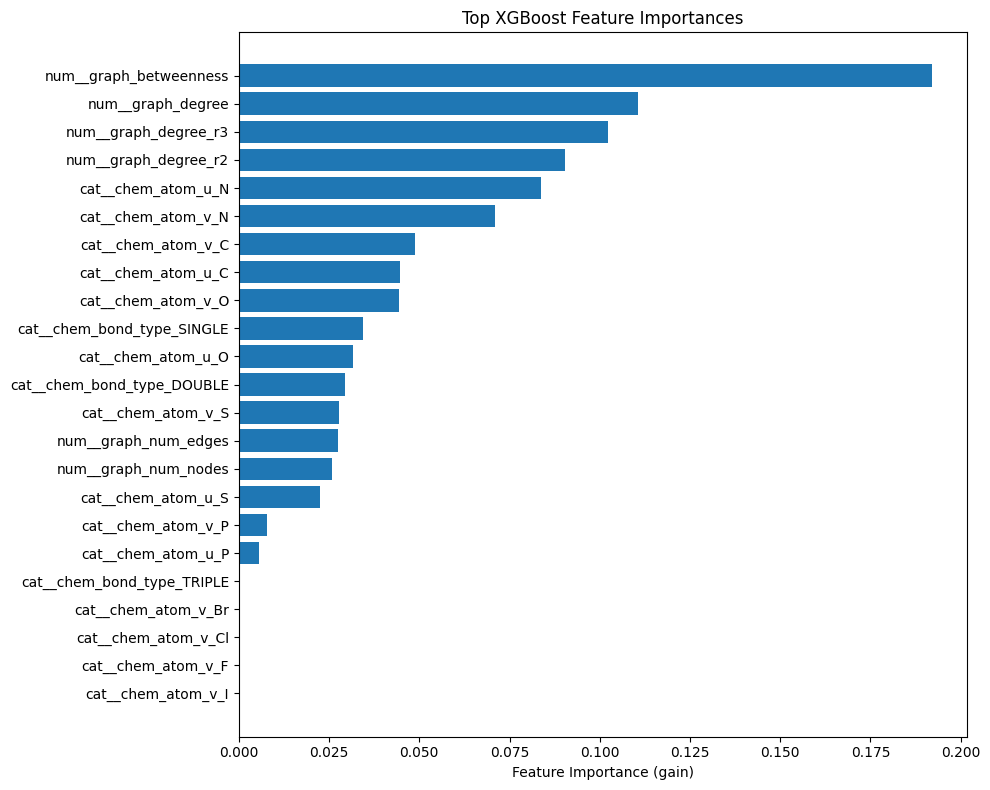

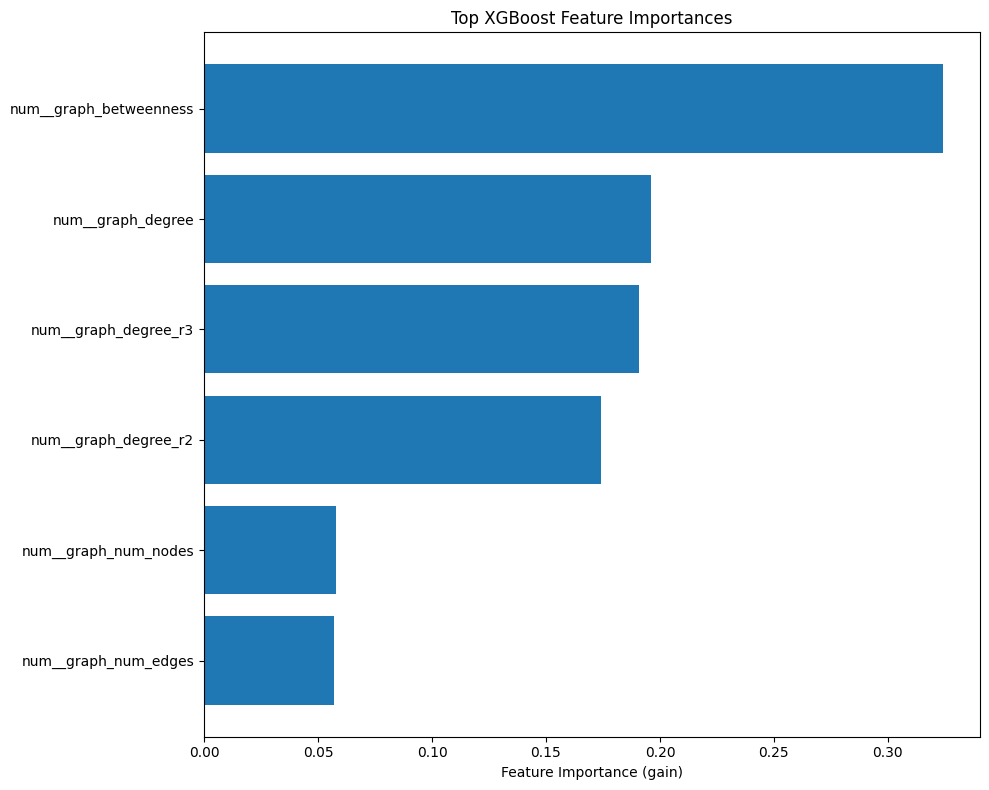

In [251]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # NOTE: from imblearn!

# --- Preprocessing transformer ---
graph_transformer = ColumnTransformer([
    # ("num", StandardScaler(), numeric_features),
    ("num", "passthrough", numeric_features),
])

full_transformer = ColumnTransformer([
    # ("num", StandardScaler(), graph_features),
    ("num", "passthrough", graph_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
])

# --- Pipeline with SMOTE ---
graph_classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", graph_classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

# Assume df is your input DataFrame
X_train = graph_train_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(graph_train_df)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# Train and evaluate
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

plot_top_feature_importances(full_pipeline, top_n=50)
plot_top_feature_importances(graph_pipeline, top_n=50)

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.99      0.91      0.94     32949
           1       0.20      0.51      0.28       996
           2       0.39      0.83      0.53       996

    accuracy                           0.89     34941
   macro avg       0.53      0.75      0.59     34941
weighted avg       0.95      0.89      0.91     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     32949
           1       0.61      0.24      0.34       996
           2       0.81      0.61      0.70       996

    accuracy                           0.96     34941
   macro avg       0.80      0.61      0.67     34941
weighted avg       0.95      0.96      0.95     34941



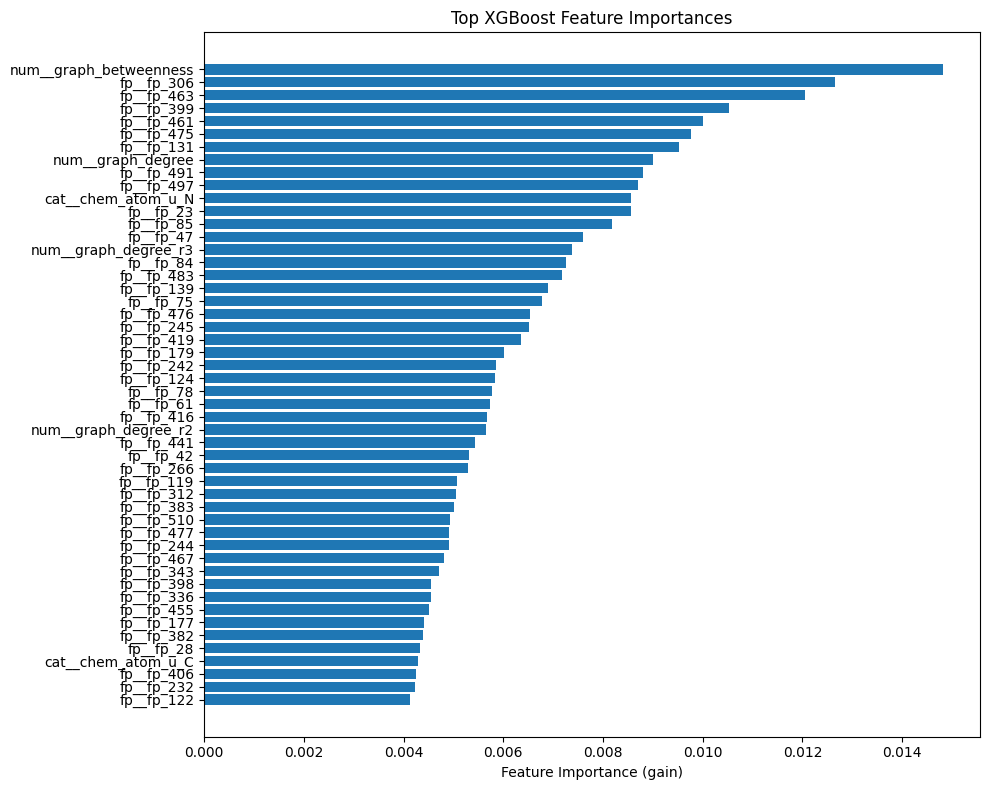

IndexError: index 337 is out of bounds for axis 0 with size 6

<Figure size 1000x800 with 0 Axes>

In [253]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier  # <-- import XGBoost classifier

# --- Preprocessing transformers ---
graph_transformer = ColumnTransformer([
    ("num", "passthrough", numeric_features),
])

full_transformer = ColumnTransformer([
    ("num", "passthrough", graph_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
    # ("smiles", make_pipeline(MorganFingerprintTransformer(radius=8, n_bits=512)), ["chem_smiles"]),  # custom pipeline
    # ("desc", make_pipeline(
    #     RDKitDescriptorTransformer(),
    #     SimpleImputer(strategy="constant", fill_value=0.0),
    #     StandardScaler()), ["chem_smiles"]) # To handle NaN values
    ("desc", StandardScaler(), descriptor_features),
    ("fp", "passthrough", fingerprint_features),
])

# --- XGBoost classifier ---
graph_classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

# --- Pipelines ---
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", graph_classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

# --- Target & Features ---
# Shuffle graph_train_df
X = graph_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = X.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(X)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# --- Train and Evaluate ---
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

plot_top_feature_importances(full_pipeline, top_n=50)
plot_top_feature_importances(graph_pipeline, top_n=50)

In [198]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier  # <-- import XGBoost classifier

# --- Preprocessing transformers ---
graph_transformer = ColumnTransformer([
    ("num", "passthrough", numeric_features),
])

full_transformer = ColumnTransformer([
    ("num", "passthrough", graph_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
    # ("desc", StandardScaler(), descriptor_features),
    ("fp", "passthrough", fingerprint_features),
])

# --- XGBoost classifier ---
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

# --- Pipelines ---
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

# --- Target & Features ---
# Shuffle graph_train_df
X = graph_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = X.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(X)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# --- Train and Evaluate ---
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     32949
           1       0.29      0.40      0.34       996
           2       0.58      0.77      0.66       996

    accuracy                           0.94     34941
   macro avg       0.62      0.71      0.66     34941
weighted avg       0.95      0.94      0.94     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     32949
           1       0.64      0.23      0.34       996
           2       0.83      0.63      0.72       996

    accuracy                           0.96     34941
   macro avg       0.81      0.62      0.68     34941
weighted avg       0.95      0.96      0.95     34941



With SVD on the fingerprints, having around 100 components seems to be a good choice (even though PCA shows around 600 for explaining 95% variance).

=== Graph-only features ===
              precision    recall  f1-score   support

           0       0.99      0.91      0.94     32949
           1       0.20      0.51      0.28       996
           2       0.39      0.83      0.53       996

    accuracy                           0.89     34941
   macro avg       0.53      0.75      0.59     34941
weighted avg       0.95      0.89      0.91     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     32949
           1       0.49      0.29      0.37       996
           2       0.77      0.64      0.70       996

    accuracy                           0.96     34941
   macro avg       0.74      0.64      0.68     34941
weighted avg       0.95      0.96      0.95     34941



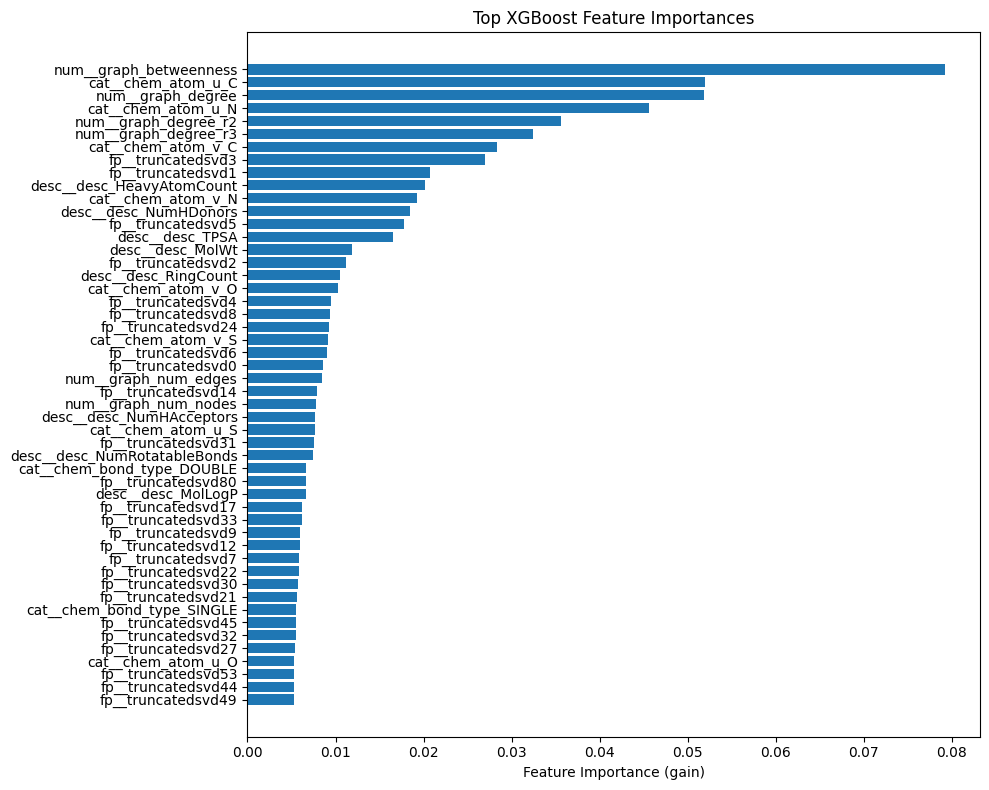

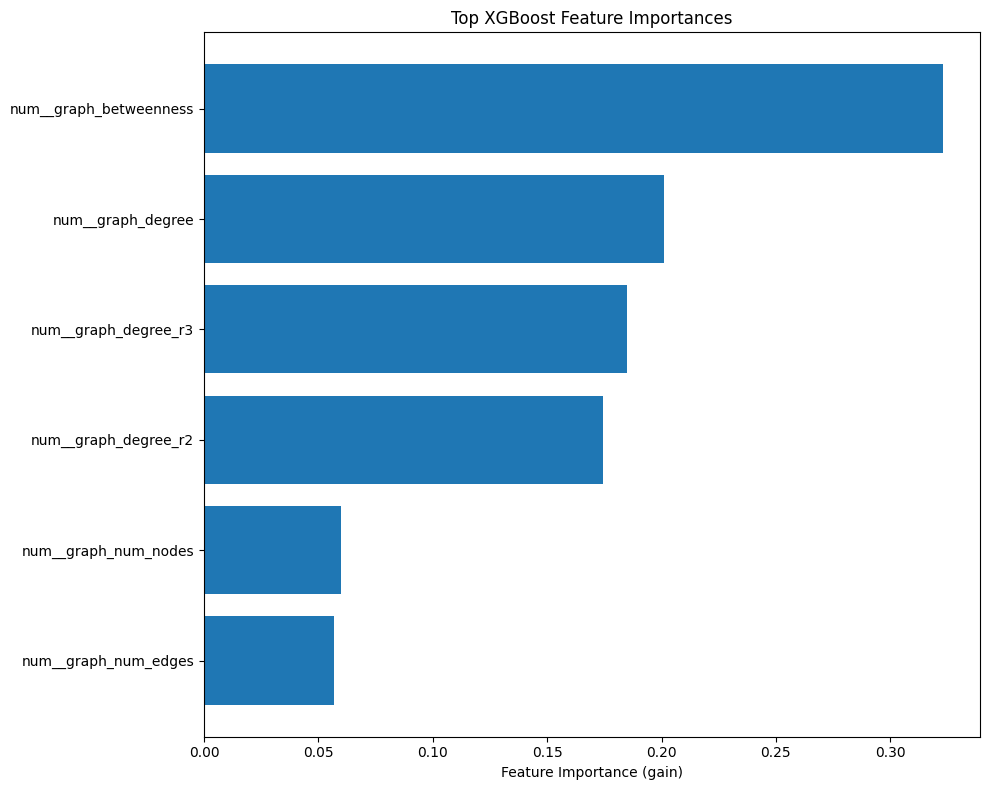

In [255]:
from sklearn.decomposition import TruncatedSVD

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier  # <-- import XGBoost classifier

# --- Preprocessing transformers ---
graph_transformer = ColumnTransformer([
    ("num", "passthrough", numeric_features),
])

full_transformer = ColumnTransformer([
    ("num", "passthrough", graph_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # ("bool", "passthrough", boolean_features),
    # ("desc", StandardScaler(), descriptor_features),
    ("desc", "passthrough", descriptor_features),
    # ("fp", "passthrough", fingerprint_features),
    # ("chem_block", make_pipeline(TruncatedSVD(n_components=pca_n_components, random_state=42)), descriptor_features + fp_columns)
    # ("chem_block", make_pipeline(PCA(n_components=0.95, random_state=42)), descriptor_features + fp_columns)
    ("fp", make_pipeline(TruncatedSVD(n_components=100, random_state=42)), fp_columns)
])

# --- XGBoost classifier ---
graph_classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

# --- Pipelines ---
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    # ("pca", PCA(n_components=0.95, random_state=42)),
    # ("svd", TruncatedSVD(n_components=0.95, random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("clf", graph_classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    # ("pca", PCA(n_components=0.95, random_state=42)),
    # ("svd", TruncatedSVD(n_components=117, random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("clf", classifier)
])

# --- Target & Features ---
# Shuffle graph_train_df
X = graph_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = X.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(X)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# --- Train and Evaluate ---
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

plot_top_feature_importances(full_pipeline, top_n=50)
plot_top_feature_importances(graph_pipeline, top_n=50)

In [204]:
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import ClusterCentroids, RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier  # <-- import XGBoost classifier

# --- Preprocessing transformers ---
graph_transformer = ColumnTransformer([
    ("num", "passthrough", numeric_features),
])

full_transformer = ColumnTransformer([
    ("num", "passthrough", graph_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("bool", "passthrough", boolean_features),
    # ("desc", StandardScaler(), descriptor_features),
    # ("fp", "passthrough", fingerprint_features),
    ("fp", make_pipeline(TruncatedSVD(n_components=100, random_state=42)), fp_columns)
])

# --- XGBoost classifier ---
classifier = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",     # required for multiclass
    objective="multi:softprob", # optional, softmax for multiclass
    tree_method="hist"          # faster histogram-based grow
)

# --- Pipelines ---
graph_pipeline = Pipeline([
    ("preprocess", graph_transformer),
    # ("smote", SMOTEENN(random_state=42)),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("clf", classifier)
])

full_pipeline = Pipeline([
    ("preprocess", full_transformer),
    # ("smote", SMOTEENN(random_state=42)),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("clf", classifier)
])

# --- Target & Features ---
# Shuffle graph_train_df
X = graph_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = X.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_train = build_multiclass_target(X)

X_test = graph_test_df.drop(columns=["label_is_split", "label_e3_split", "label_wh_split"])
y_test = build_multiclass_target(graph_test_df)

# --- Train and Evaluate ---
print("=== Graph-only features ===")
graph_pipeline.fit(X_train, y_train)
y_pred_graph = graph_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_graph))

print("=== Graph + Chem features ===")
full_pipeline.fit(X_train, y_train)
y_pred_full = full_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_full))

=== Graph-only features ===
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     32949
           1       0.14      0.78      0.23       996
           2       0.30      0.90      0.45       996

    accuracy                           0.80     34941
   macro avg       0.48      0.83      0.52     34941
weighted avg       0.95      0.80      0.85     34941

=== Graph + Chem features ===
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     32949
           1       0.14      0.85      0.24       996
           2       0.38      0.91      0.53       996

    accuracy                           0.81     34941
   macro avg       0.51      0.86      0.56     34941
weighted avg       0.95      0.81      0.86     34941



---

In [ ]:


def get_predictions(row):
    """
    Get the predictions for a given row of the dataframe.
    """
    ret = nx_split(row['PROTAC SMILES'], representative_e3s_fp, morgan_fp_generator, use_capacity_weight=False, betweenness_threshold=0.4)
    row['POI Ligand SMILES with direction'] = ret['e3']
    row['Linker SMILES with direction'] = ret['poi']
    row['E3 Binder SMILES with direction'] = ret['linker']
    return row

# Apply the function to the dataframe
tqdm.pandas(desc="Getting predictions")
nx_predictions_df = held_out_df.progress_apply(get_predictions, axis=1)

In [ ]:
from datasets import load_dataset

def get_substructs(row):
    ret = nx_split(row['text'], representative_e3s_fp, morgan_fp_generator, use_capacity_weight=False, betweenness_threshold=0.4)
    return {
        'PROTAC SMILES': row['text'],
        'POI Ligand SMILES with direction': ret['poi'],
        'Linker SMILES with direction': ret['linker'],
        'E3 Binder SMILES with direction': ret['e3'],
    }


tmp = load_dataset('ailab-bio/PROTAC-Splitter-Dataset', 'clustered', split='held_out')
tmp = tmp.map(get_substructs, num_proc=8, remove_columns=['text', 'labels']).to_pandas()
tmp.nunique()

In [ ]:
tmp

---

## Possible Ideas for the Future

Bridges found: [(0, 1), (7, 8), (11, 12), (12, 13), (22, 23), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (36, 37), (37, 38), (38, 39), (38, 40), (40, 41), (47, 48), (49, 50), (53, 54), (56, 57), (58, 59)]


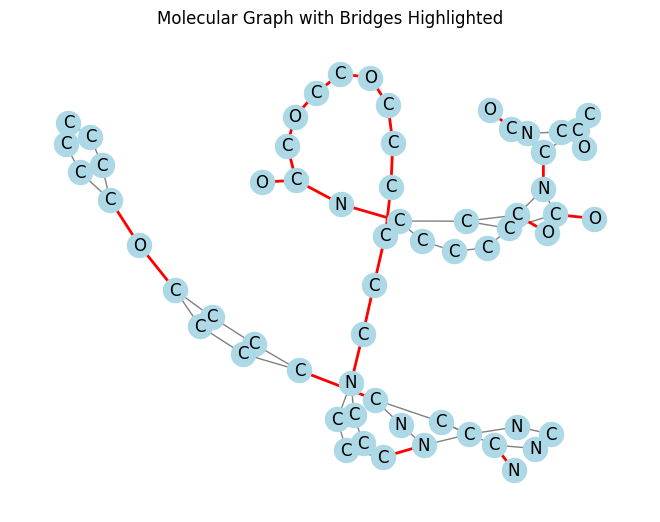

In [290]:
def find_bridges(G):
    return list(nx.bridges(G))

def visualize_graph(G, bridges):
    pos = nx.spring_layout(G)
    elements = nx.get_node_attributes(G, 'element')
    nx.draw(G, pos, with_labels=True, labels=elements, node_color='lightblue', edge_color='gray')
    nx.draw_networkx_edges(G, pos, edgelist=bridges, edge_color='red', width=2)
    plt.title("Molecular Graph with Bridges Highlighted")
    plt.show()

G = smiles_to_nx(protac_smiles)
bridges = find_bridges(G)
print("Bridges found:", bridges)
visualize_graph(G, bridges)

In [291]:
from networkx.algorithms.flow import (
    shortest_augmenting_path,
    preflow_push,
    dinitz,
    edmonds_karp,
    boykov_kolmogorov,
    capacity_scaling,
)


def find_min_cut(G, source, target):
    cut_value, partition = nx.minimum_cut(G, source, target, capacity='capacity')
    reachable, non_reachable = partition
    cutset = set()
    for u in reachable:
        for v in G[u]:
            if v in non_reachable:
                cutset.add((u, v))
    return cut_value, cutset

def construct_gomory_hu_tree(G):
    return nx.gomory_hu_tree(G, capacity='capacity')

def min_cut_from_gomory_hu(T, u, v):
    path = nx.shortest_path(T, u, v, weight='weight')
    min_weight = float('inf')
    min_edge = None
    for i in range(len(path) - 1):
        weight = T[path[i]][path[i+1]]['weight']
        if weight < min_weight:
            min_weight = weight
            min_edge = (path[i], path[i+1])
    return min_weight, min_edge

protac = Chem.MolFromSmiles(protac_smiles)
# Get the number of atoms in the molecule
num_atoms = protac.GetNumAtoms()
print(f'Number of atoms in the molecule: {num_atoms}')

G = smiles_to_nx(protac_smiles)

# Apply Minimum Cut between two nodes (e.g., 0 and num_atoms-1)
cut_value, cutset = find_min_cut(G, 0, num_atoms-1)
print("Minimum Cut Value:", cut_value)
print("Cutset Edges:", cutset)

# Construct Gomory–Hu Tree
T = construct_gomory_hu_tree(G)

# Find minimum cut between two nodes using Gomory–Hu Tree
min_weight, min_edge = min_cut_from_gomory_hu(T, 0, num_atoms-1)
print("Gomory-Hu Tree Minimum Cut Value:", min_weight)
print("Gomory-Hu Tree Cut Edge:", min_edge)

Number of atoms in the molecule: 62
Minimum Cut Value: 1
Cutset Edges: {(22, 23)}
Gomory-Hu Tree Minimum Cut Value: 1
Gomory-Hu Tree Cut Edge: (0, 1)


In [ ]:
from collections import defaultdict
import networkx as nx
import numpy as np
import community as community_louvain  # Requires the 'python-louvain' package
from rdkit import Chem
from rdkit.Chem import Draw


def detect_communities(G):
    partition = community_louvain.best_partition(G, randomize=False, weight='capacity', resolution=1)
    return partition

def compute_cut_sizes(G, partition, weight=None):
    # Organize nodes by their partition
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    # Compute cut sizes between each pair of partitions
    cut_sizes = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            cut = nx.cut_size(G, comm_i, comm_j, weight=weight)
            cut_sizes[(comm_ids[i], comm_ids[j])] = cut
    return cut_sizes

def compute_conductance(G, partition, weight=None):
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    conductance_values = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            cond = nx.conductance(G, comm_i, T=comm_j, weight=weight)
            conductance_values[(comm_ids[i], comm_ids[j])] = cond
    return conductance_values

def compute_normalized_cut(G, partition, weight=None):
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    normalized_cuts = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            ncut = nx.normalized_cut_size(G, comm_i, T=comm_j, weight=weight)
            normalized_cuts[(comm_ids[i], comm_ids[j])] = ncut
    return normalized_cuts

def compute_balance_ratios(partition):
    from itertools import combinations
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    balance_ratios = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            size_i = len(communities[comm_ids[i]])
            size_j = len(communities[comm_ids[j]])
            ratio = min(size_i, size_j) / max(size_i, size_j)
            balance_ratios[(comm_ids[i], comm_ids[j])] = ratio
    return balance_ratios


def get_representative_nodes(G, partition):
    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)
    
    representatives = {}
    for comm_id, nodes in communities.items():
        subgraph = G.subgraph(nodes)
        degrees = subgraph.degree()
        # Select node with highest degree
        rep_node = max(degrees, key=lambda x: x[1])[0]
        representatives[comm_id] = rep_node
    return representatives

def compute_average_edge_betweenness(G, cutset):
    betweenness = nx.edge_betweenness_centrality(G)
    return sum(betweenness[edge] for edge in cutset) / len(cutset)

def visualize_graph(G, partition, cutset):
    pos = nx.spring_layout(G)
    # Color nodes by community
    communities = set(partition.values())
    colors = plt.cm.rainbow(np.linspace(0, 1, len(communities)))
    color_map = dict(zip(communities, colors))
    node_colors = [color_map[partition[node]] for node in G.nodes()]
    
    nx.draw(G, pos, node_color=node_colors, with_labels=True, edge_color='gray')
    # Highlight cutset edges
    nx.draw_networkx_edges(G, pos, edgelist=cutset, edge_color='red', width=2)
    plt.title("Graph with Dense Regions and Connecting Chain Highlighted")
    plt.show()
    
def rank_partitions(cut_sizes, conductances, normalized_cuts, balance_ratios,
                    w_cut=1.0, w_conduct=1.0, w_ncut=1.0, w_balance=1.0):
    rankings = []
    for pair in cut_sizes:
        cut = cut_sizes[pair]
        cond = conductances.get(pair, float('inf'))
        ncut = normalized_cuts.get(pair, float('inf'))
        balance = balance_ratios.get(pair, 0.0)

        # Combine into a score: lower is better
        score = (
            w_cut * cut +
            w_conduct * cond +
            w_ncut * ncut -
            w_balance * balance  # because higher balance is better
        )
        rankings.append((pair, score))
    
    # Sort by score ascending (lower score = better partition)
    rankings.sort(key=lambda x: x[1])
    return rankings


G = smiles_to_nx(protac_smiles)
partition = detect_communities(G)

# Get the representative nodes for the top-ranked partitions
representative_nodes = get_representative_nodes(G, partition)

cut_sizes = compute_cut_sizes(G, partition)
conductances = compute_conductance(G, partition)
normalized_cuts = compute_normalized_cut(G, partition)
balance_ratios = compute_balance_ratios(partition)

# Rank partitions based on the metrics
rankings = rank_partitions(cut_sizes, conductances, normalized_cuts, balance_ratios, w_cut=1, w_conduct=1, w_ncut=1, w_balance=1)

all_nodes = set(G.nodes())
num_splits = 0

print("Top-ranked partitions:")
for (partition1, partition2), score in rankings:
    
    node1 = representative_nodes[partition1]
    node2 = representative_nodes[partition2]

    print(f"Partition Pair: {(partition1, partition2)}, Score: {score:.4f}")
    print(f"  Representative Nodes: {node1}, {node2}\n")

    cut_value, cutsets = find_min_cut(G, node1, node2)

    # Find minimum cut between two nodes using Gomory–Hu Tree
    T = construct_gomory_hu_tree(G)
    _, cutset = min_cut_from_gomory_hu(T, node1, node2)
    cutsets = [cutset]

    # Check if the tuple in the cutset is the same as the edge between E3 and WH
    for cutset in cutsets:
        if (e3_edge[0] in cutset and e3_edge[1] in cutset) or (wh_edge[0] in cutset and wh_edge[1] in cutset):
            print()
            print(f"Cutset contains the edge between E3 and WH: {cutset}")
            break

    # betweenness = compute_average_edge_betweenness(G, cutsets)
    # print(f"Cutset: {cutsets}, value: {cut_value}, betweenness: {betweenness}")

    for cutset in cutsets:
        if (e3_edge[0] in cutset and e3_edge[1] in cutset) or (wh_edge[0] in cutset and wh_edge[1] in cutset):
            print()
            break

    for cutset in cutsets:
        node1, node2 = cutset
        break

    # Ensure the splitting nodes are not the same as before
    if node1 not in all_nodes or node2 not in all_nodes:
        continue

    # Remove the representative nodes from the set of all nodes
    all_nodes.remove(node1)
    all_nodes.remove(node2)
    
    purple = (1, 0, 1, 0.3)
    display(Draw.MolToImage(
        protac,
        size=(1500, 400),
        highlightColor=purple,
        highlightAtoms=[node1, node2],
    ))

    num_splits += 1
    if num_splits >= 50:
        break